In [1]:
import sys
import os

running_path = "/Odyssey/private/o23gauvr/code/"
os.chdir(running_path)
sys.path.insert(0,running_path)
sys.path.insert(0, "/Odyssey/private/o23gauvr/code/FASCINATION")
#from FASCINATION.src.autoencoder_datamodule_good_split import AEDatamodule

import numpy as np
import xarray as xr
from pathlib import Path
import pickle
import torch
import torch.nn as nn
from MLIC.MLIC.models import MLICPlusPlus
from MLIC.MLIC.utils.utils import Config
from pathlib import Path
from tqdm import tqdm
from scipy.ndimage import convolve
from scipy.signal import butter, filtfilt




from FASCINATION.src.utils import unorm_ssp_arr_3D



# Functions

In [2]:


def parse_experiment_config(ckpt_path):
    """
    Parse experiment_config.log file to extract N and M values.
    
    Args:
        ckpt_path (str): PosixPath to checkpoint 
        
    Returns:
        tuple: (N, M) values or (None, None) if parsing fails
    """

    config_file = list((ckpt_path.parent.parent).rglob("train_*.log")) 
    if not config_file:
        print(f"Warning: train logs not found in {ckpt_path}")
        return None, None
    
    config_file = config_file[0]  # Get the first match if multiple found

    try:
        with open(config_file, 'r') as f:
            content = f.read()
        
        # Extract N and M values from MODEL CONFIGURATION section
        N, M = None, None
        
        lines = content.split('\n')

        cfg = eval((lines[1].strip().split("INFO: ")[-1]).replace("<class 'torch.nn.modules.activation.","nn.").replace("'>",""))


        return cfg
        
            
    except Exception as e:
        print(f"Error parsing config file in {ckpt_path}: {e}")
        return None




In [3]:


def get_min_max_idx(arr: np.ndarray, axs: int = 1, pad: bool = True) -> np.ndarray:
    grad = np.diff(arr, axis=axs)
    grad_sign = np.sign(grad)
    min_max = np.abs(np.sign(np.diff(grad_sign, axis=axs)))
    if pad:
        # pad for 4D arrays (t, z, lat, lon)
        pad_width = [(0, 0)] * arr.ndim
        pad_width[axs] = (1, 1)
        min_max = np.pad(min_max, pad_width, 'constant', constant_values=1)
    return min_max


def get_f1_score(min_max_idx_truth: np.ndarray, min_max_idx_ae: np.ndarray, axs: int = 1, kernel_size: int = 10) -> np.ndarray:
    kernel_shape = [1] * min_max_idx_truth.ndim
    kernel_shape[axs] = kernel_size
    kernel = np.ones(kernel_shape)
    truth_expanded = convolve(min_max_idx_truth, kernel, mode='constant', cval=0.0)
    ae_expanded = convolve(min_max_idx_ae, kernel, mode='constant', cval=0.0)
    true_positives = (truth_expanded > 0) & (min_max_idx_ae > 0)
    num_true_positives = np.sum(true_positives, axis=axs)
    false_positives = (truth_expanded == 0) & (min_max_idx_ae > 0)
    num_false_positives = np.sum(false_positives, axis=axs)
    false_negatives = (min_max_idx_truth > 0) & (ae_expanded == 0)
    num_false_negatives = np.sum(false_negatives, axis=axs)
    precision_den = num_true_positives + num_false_positives
    recall_den = num_true_positives + num_false_negatives
    precision_score = np.where(precision_den == 0, 0, num_true_positives / precision_den)
    recall_score = np.where(recall_den == 0, 0, num_true_positives / recall_den)
    sum_scores = precision_score + recall_score
    f1_score = np.where(sum_scores == 0, 0, 2 * (precision_score * recall_score) / sum_scores)
    return f1_score


# Load Data

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cpu"


In [5]:
with open("/Odyssey/private/o23gauvr/code/FASCINATION/pickle/model_metrics_enatl_test.pkl", "rb") as f:
    model_metrics = pickle.load(f)

with open("/Odyssey/private/o23gauvr/code/FASCINATION/pickle/data_dict_enatl_test.pkl", "rb") as f:
    data_dict = pickle.load(f)


In [6]:
#data_path = "/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_dm_157_196_256_good_split.pkl"
from FASCINATION.src.autoencoder_datamodule_natl_enatl import AEDatamodule, AE_BaseDataset_3D

data_path = "/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_natl_dm_157_196_256_norm_per_split.pkl" #"/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_dm_157_196_256_good_split.pkl"  #"/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_dm_157_128_192_good_split.pkl" #"/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_dm_157_196_256_good_split.pkl"
with open(data_path, 'rb') as f:
    dm = pickle.load(f)

In [7]:
# dm_path = "/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_dm_157_140_240_good_split.pkl"
# with open(dm_path, 'rb') as f:
#     dm_140_240 = pickle.load(f) 

In [8]:
dm_path = "/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_dm_157_196_256_norm_per_split.pkl" #"/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_dm_157_196_256_good_split.pkl" #
with open(dm_path, 'rb') as f:
    dm_enatl = pickle.load(f)

In [9]:
ssp_da = dm.test_ds.input
depth_array = ssp_da.z.values
test_norm = ssp_da.attrs['norm_stats']
season_idx = dm.test_ds.input.season_idx
sst_test_norm  = dm.test_ds.input.attrs['sst'].data


In [10]:
ssp_da.mean(), ssp_da.shape

(<xarray.DataArray 'celerity' ()> Size: 4B
 array(0., dtype=float32),
 (164, 157, 192, 256))

In [11]:
# train_time = dm_enatl.train_ds.input.time.values
# test_time = dm_enatl.test_ds.input.time.values

# train_months = np.unique(dm_enatl.train_ds.input.time.dt.month.values)
# test_months = np.unique(dm_enatl.test_ds.input.time.dt.month.values)
# ssp_da = ssp_da.where(ssp_da.time.dt.month.isin(test_months), drop=True)
# ssp_da.shape

In [12]:
# Select profile near source location
ssp_truth = ssp_da.values
ssp_truth = unorm_ssp_arr_3D(ssp_truth, test_norm)



In [13]:
ssp_truth.mean()

np.float32(1507.9906)

In [14]:
# ssp_da_140 = dm_140_240.test_ds.input
# test_norm = ssp_da_140.attrs['norm_stats']

# # Select profile near source location
# ssp_truth_140 = ssp_da_140.values
# ssp_truth_140 = unorm_ssp_arr_3D(ssp_truth_140, test_norm)



In [15]:
cr = "10000"
ckpt_file = Path("/Odyssey/private/o23gauvr/code/MLIC/experiments/test_enatl_natl_mse/fixed_weight_loss_64_96_1.0_CR_10000.0_enatl_natl__mean_std/20260402_154931/checkpoints/best_checkpoint_bpp_loss.pth.tar")
#ckpt_file = list(Path("/Odyssey/private/o23gauvr/code/FASCINATION/outputs/remote/outputs/eusipco/MLIC/SSP").glob(f"fixed_weight_loss_64_96_1.0_CR_{cr}.0*/**/*_rmse.pth.tar"))[0]
cfg = parse_experiment_config(ckpt_file)
N = cfg.get('N', 192)
M = cfg.get('M', 320)
ssp_config = Config({
    'N': N, 'M': M, 'slice_num': cfg.get('slice_num', 10),
    'context_window': cfg.get('context_window', 5), 'act': cfg.get('act', nn.GELU),
    'in_channels': cfg.get('in_channels', 157), 'out_channels': cfg.get('in_channels', 157), 
    "add_seasons": cfg.get("add_seasons", {"use": False, "mode": None}),
    "add_sst": cfg.get("add_sst", False)
})

try:
    cr = str(ckpt_file).split("CR_")[-1].split("_")[0]
except:
    cr = ""



        

In [16]:
dm_enatl.train_ds.input.attrs['norm_stats']['params']['mean'], dm_enatl.test_ds.input.attrs['norm_stats']['params']['mean']

(np.float64(1510.9398727627265), np.float64(1508.9220275010182))

In [17]:
dm.train_ds.input.attrs['norm_stats']['params']['mean'], dm.test_ds.input.attrs['norm_stats']['params']['mean']

(np.float64(1510.072869113682), np.float64(1507.9905796290636))

In [18]:
#test_norm = dm_enatl.train_ds.input.attrs['norm_stats']


try:
    net = MLICPlusPlus(config=ssp_config).eval().to(device)
    ck = torch.load(ckpt_file, map_location=device)
    if "one_hot_old" in str(ckpt_file) or str(ckpt_file) == "/Odyssey/private/o23gauvr/code/MLIC/experiments/full_loss_batch_4_add_season_hot_one_64_96_0.0018_min_max/20251001_001608/checkpoints/checkpoint_best_loss.pth.tar":
        del ck['state_dict']["season_embed.weight"]
    net.load_state_dict(ck['state_dict'])


    # test_norm = ck.get('test_norm_stats', None)
    # test_norm_method = test_norm['method']
    test_norm = ck['test_norm_stats'] #ck.get('test_norm_stats', dm.test_ds.input.attrs['norm_stats'])
    test_norm_method = ck.get('test_norm_stats', {"method": "min_max"})['method']
    
    if test_norm_method == "min_max":
        x_min = test_norm["params"]["x_min"].astype(ssp_truth.dtype)
        x_max = test_norm["params"]["x_max"].astype(ssp_truth.dtype)    
        ssp_truth = (ssp_truth - x_min) / (x_max - x_min)
    elif test_norm_method == "mean_std":
        mean = test_norm['params']["mean"].astype(ssp_truth.dtype)
        std = test_norm['params']["std"].astype(ssp_truth.dtype)
        ssp_truth = (ssp_truth - mean) / std
    elif test_norm_method == "mean_std_along_depth":
        mean = test_norm['params']["mean_along_depth"].astype(ssp_truth.dtype)
        std = test_norm['params']["std_along_depth"].astype(ssp_truth.dtype)
        ssp_truth = (ssp_truth - mean) / std

except Exception as e:
    print(f"Error loading model or normalizing data: {e}")



/Odyssey/private/o23gauvr/miniforge3/envs/fsc/lib/python3.11/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1720538435607/work/aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/tmp/ipykernel_2604753/588120858.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode

In [19]:
ck['train_norm_stats']['params']['mean'] ,ck['test_norm_stats']['params']['mean'],

(np.float64(1510.072869113682), np.float64(1507.9905796290636))

In [20]:
test_norm['params']['mean'], test_norm['params']['std']

(np.float64(1507.9905796290636), np.float64(15.030565168037237))

In [21]:
ssp_truth.mean()

np.float32(-1.2421323e-06)

In [22]:

ssp_truth_tens = torch.tensor(ssp_truth).to(device=device, dtype=getattr(torch,dm.dtype_str))
with torch.no_grad():
    rv_batch = net(ssp_truth_tens, season_idx, sst_test_norm)

ssp_ae = rv_batch['x_hat'].detach().cpu().numpy()




In [23]:
ssp_ae.mean(), ssp_truth.mean()

(np.float32(-0.018656746), np.float32(-1.2421323e-06))

In [24]:
unorm_ssp_arr_3D(ssp_ae, test_norm).mean(), unorm_ssp_arr_3D(ssp_truth, test_norm).mean()

(np.float32(1507.7102), np.float32(1507.9906))

In [25]:
ssp_ae = unorm_ssp_arr_3D(ssp_ae, test_norm)
ssp_truth = unorm_ssp_arr_3D(ssp_truth, test_norm)

In [26]:
min_max_idx_truth = get_min_max_idx(ssp_truth, pad=False)
min_max_idx_ae = get_min_max_idx(ssp_ae, pad=False)

F1_score = get_f1_score(min_max_idx_truth, min_max_idx_ae)
f1_score = np.mean(F1_score)

/tmp/ipykernel_2604753/2648127300.py:28: RuntimeWarning: invalid value encountered in divide
  recall_score = np.where(recall_den == 0, 0, num_true_positives / recall_den)
/tmp/ipykernel_2604753/2648127300.py:30: RuntimeWarning: invalid value encountered in divide
  f1_score = np.where(sum_scores == 0, 0, 2 * (precision_score * recall_score) / sum_scores)


In [27]:
rmse = np.sqrt(np.mean((ssp_ae - ssp_truth) ** 2))
print(f"RMSE: {rmse:.4f}")
print(f"F1 Score: {f1_score:.4f}")

RMSE: 1.4827
F1 Score: 0.6273


In [28]:
ssp_truth_da = ssp_da.copy(data=ssp_truth)
ssp_ae_da = ssp_da.copy(data=ssp_ae)
# ssp_da_140 = ssp_da_140.copy(data=ssp_truth_140)

In [29]:
k = str(ckpt_file).split('.pth')[0].split('outputs/')[-1].split("experiments/")[-1].replace('/','_').replace('_checkpoints','')


In [30]:
# test_coords = dm.test_ds.input.attrs["original_space_coords"]


# ssp_truth_da = ssp_truth_da.interp(
#             lat=test_coords['lat'],
#             lon=test_coords['lon'],
#             method="nearest"
#             )


# ssp_ae_da = ssp_ae_da.interp(
#             lat=test_coords['lat'],
#             lon=test_coords['lon'],
#             method="nearest"
#             )

In [31]:
# ssp_truth_da = ssp_truth_da.isel(lat=slice(10,-10),lon=slice(10,-10))
# ssp_ae_da = ssp_ae_da.isel(lat=slice(10,-10),lon=slice(10,-10))

# Histograms

## Profiles

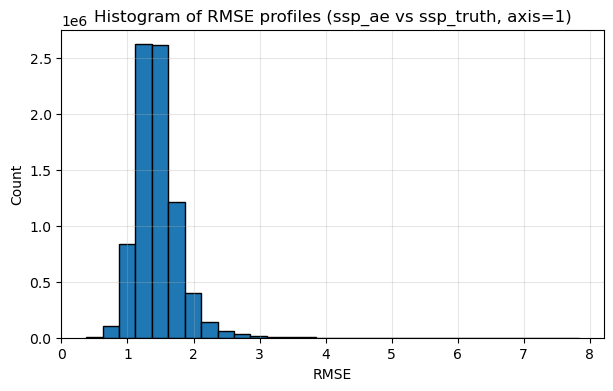

In [32]:
import matplotlib.pyplot as plt

# RMSE along 2nd dimension (axis=1, typically depth)
rmse_depth = np.sqrt(np.nanmean((ssp_ae - ssp_truth) ** 2, axis=1))

# Histogram with 20 bins (flatten all remaining dimensions)
plt.figure(figsize=(7, 4))
plt.hist(rmse_depth.ravel(), bins=30, edgecolor="black")
plt.xlabel("RMSE")
plt.ylabel("Count")
plt.title("Histogram of RMSE profiles (ssp_ae vs ssp_truth, axis=1)")
plt.grid(alpha=0.3)
plt.show()

In [33]:
print( np.sqrt(((ssp_ae_da - ssp_truth_da) ** 2).mean()))
print( np.sqrt(((ssp_ae_da.isel(lat=slice(10, -10), lon=slice(10, -10)) - ssp_truth_da) ** 2).mean()))

<xarray.DataArray 'celerity' ()> Size: 4B
array(1.4826807, dtype=float32)
<xarray.DataArray 'celerity' ()> Size: 4B
array(1.4579571, dtype=float32)


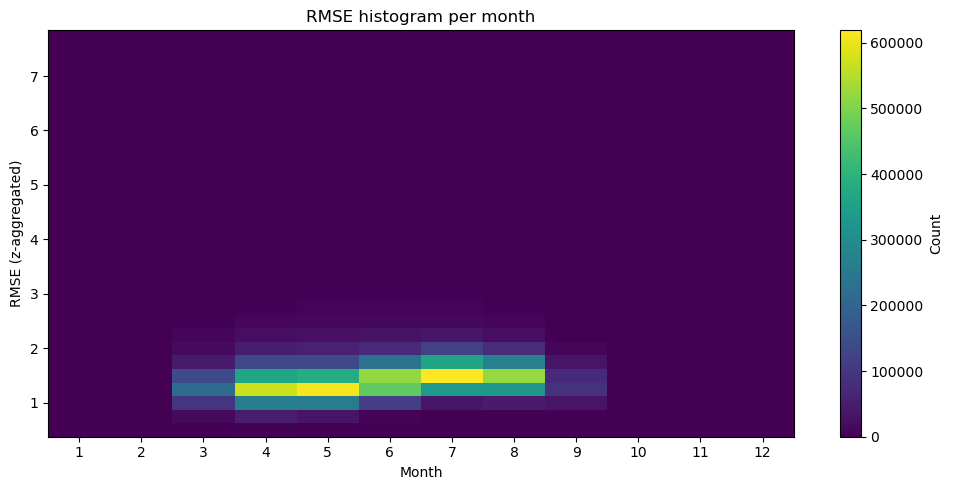

In [34]:
# RMSE along z (keeps dims: time, lat, lon)
rmse_z = np.sqrt(((ssp_ae_da - ssp_truth_da) ** 2).mean(dim="z", skipna=True))

month_idx = rmse_z["time"].dt.month.values
rmse_vals = rmse_z.values  # shape: (time, lat, lon)

# RMSE bins
valid = np.isfinite(rmse_vals)
rmse_min = np.nanmin(rmse_vals[valid])
rmse_max = np.nanmax(rmse_vals[valid])
bins = np.linspace(rmse_min, rmse_max, 31)

# Histogram count per month
hist_per_month = np.zeros((len(bins) - 1, 12), dtype=int)
for m in range(1, 13):
    mask_t = month_idx == m
    vals_m = rmse_vals[mask_t, ...].ravel()
    vals_m = vals_m[np.isfinite(vals_m)]
    hist_per_month[:, m - 1], _ = np.histogram(vals_m, bins=bins)

# Colormesh: months on x, RMSE on y, count as color
month_edges = np.arange(0.5, 13.5, 1.0)  # 12 month bins -> 13 edges

plt.figure(figsize=(10, 5))
pcm = plt.pcolormesh(month_edges, bins, hist_per_month, shading="auto")
plt.xlim(0.5, 12.5)
plt.xticks(np.arange(1, 13))
plt.xlabel("Month")
plt.ylabel("RMSE (z-aggregated)")
plt.title("RMSE histogram per month")
cbar = plt.colorbar(pcm)
cbar.set_label("Count")
plt.tight_layout()
plt.show()

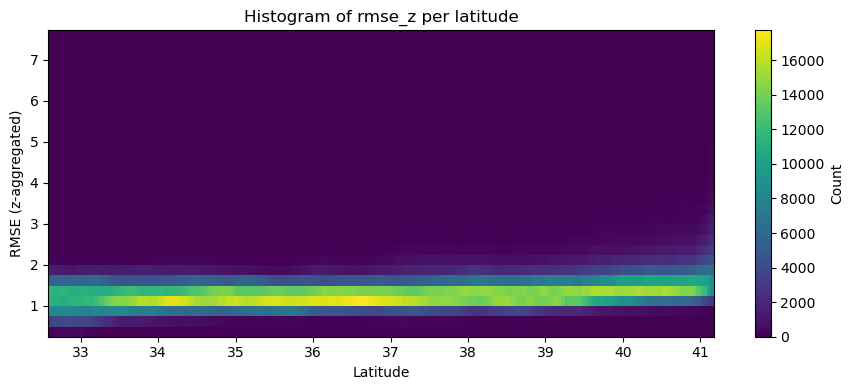

In [35]:
# Histogram of rmse_z per latitude coordinate (time/lon collapsed)
rmse_vals = rmse_z.values  # expected shape: (time, lat, lon)
lat_vals = rmse_z["lat"].values

# RMSE bins
rmse_min = np.nanmin(rmse_vals)
rmse_max = np.nanmax(rmse_vals)
bins = np.linspace(rmse_min, rmse_max, 31)

# Count histogram per latitude
hist_per_lat = np.zeros((len(lat_vals), len(bins) - 1), dtype=int)
for i in range(len(lat_vals)):
    vals_i = rmse_vals[:, i, :].ravel()
    vals_i = vals_i[np.isfinite(vals_i)]
    hist_per_lat[i], _ = np.histogram(vals_i, bins=bins)

# Plot as 2D histogram heatmap
plt.figure(figsize=(9, 4))
plt.pcolormesh(lat_vals, bins[:-1], hist_per_lat.T, shading="auto")
plt.xlabel("Latitude")
plt.ylabel("RMSE (z-aggregated)")
plt.title("Histogram of rmse_z per latitude")
cbar = plt.colorbar()
cbar.set_label("Count")
plt.tight_layout()
plt.show()

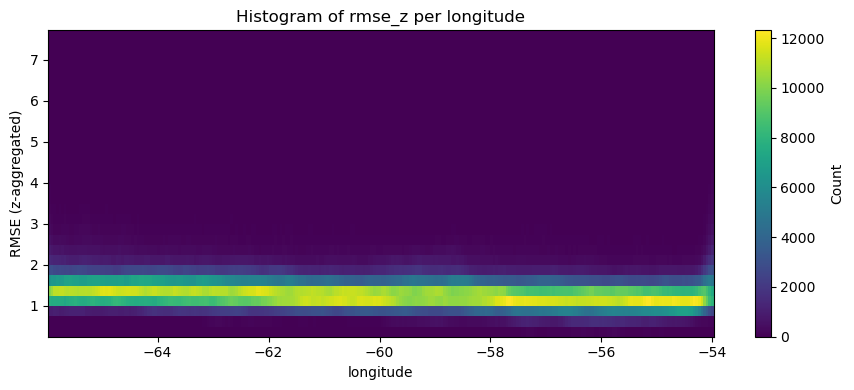

In [36]:
# Histogram of rmse_z per longitude coordinate (time/lon collapsed)
rmse_vals = rmse_z.values  # expected shape: (time, lon, lon)
lon_vals = rmse_z["lon"].values

# RMSE bins
rmse_min = np.nanmin(rmse_vals)
rmse_max = np.nanmax(rmse_vals)
bins = np.linspace(rmse_min, rmse_max, 31)

# Count histogram per longitude
hist_per_lon = np.zeros((len(lon_vals), len(bins) - 1), dtype=int)
for i in range(len(lon_vals)):
    vals_i = rmse_vals[:, :, i].ravel()
    vals_i = vals_i[np.isfinite(vals_i)]
    hist_per_lon[i], _ = np.histogram(vals_i, bins=bins)

# Plot as 2D histogram heatmap
plt.figure(figsize=(9, 4))
plt.pcolormesh(lon_vals, bins[:-1], hist_per_lon.T, shading="auto")
plt.xlabel("longitude")
plt.ylabel("RMSE (z-aggregated)")
plt.title("Histogram of rmse_z per longitude")
cbar = plt.colorbar()
cbar.set_label("Count")
plt.tight_layout()
plt.show()

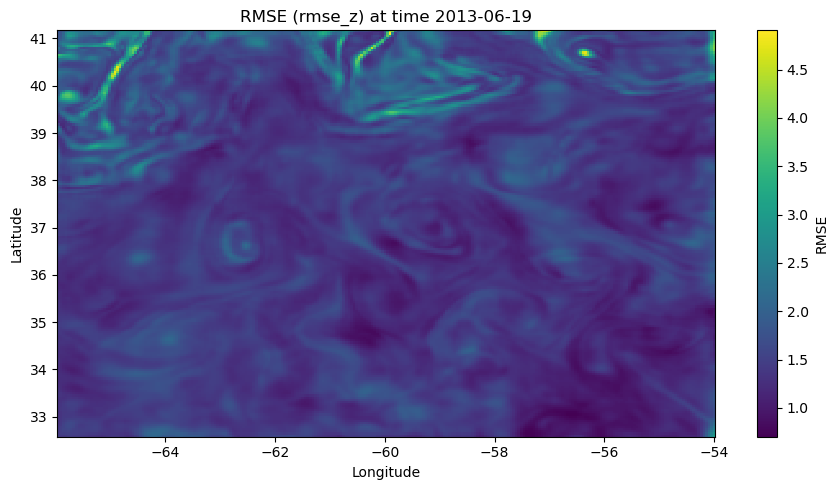

In [37]:
t=90
rmse_z_mean_time = rmse_z.isel(time=t)


lon_vals = rmse_z_mean_time["lon"].values
lat_vals = rmse_z_mean_time["lat"].values
lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)

plt.figure(figsize=(9, 5))
pcm = plt.pcolormesh(lon_grid, lat_grid, rmse_z_mean_time.values, shading="auto")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"RMSE (rmse_z) at time {ssp_da.time[t].values.astype('datetime64[D]')}")
cbar = plt.colorbar(pcm)
cbar.set_label("RMSE")
plt.tight_layout()
plt.show()

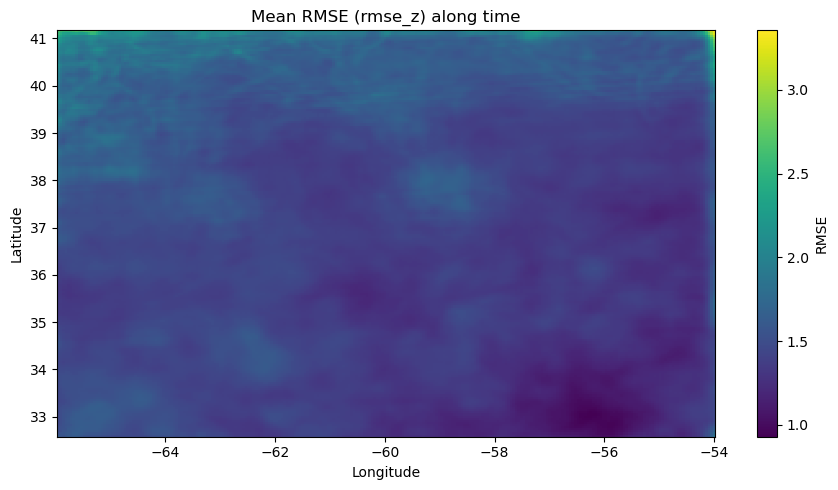

In [38]:
rmse_z_mean_time = rmse_z.mean(dim="time", skipna=True)


lon_vals = rmse_z_mean_time["lon"].values
lat_vals = rmse_z_mean_time["lat"].values
lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)

v_max = np.nanmax(rmse_z_mean_time.values)
v_min = np.nanmin(rmse_z_mean_time.values)

plt.figure(figsize=(9, 5))
pcm = plt.pcolormesh(lon_grid, lat_grid, rmse_z_mean_time.values, shading="auto")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Mean RMSE (rmse_z) along time")
cbar = plt.colorbar(pcm)
cbar.set_label("RMSE")
plt.tight_layout()
plt.show()

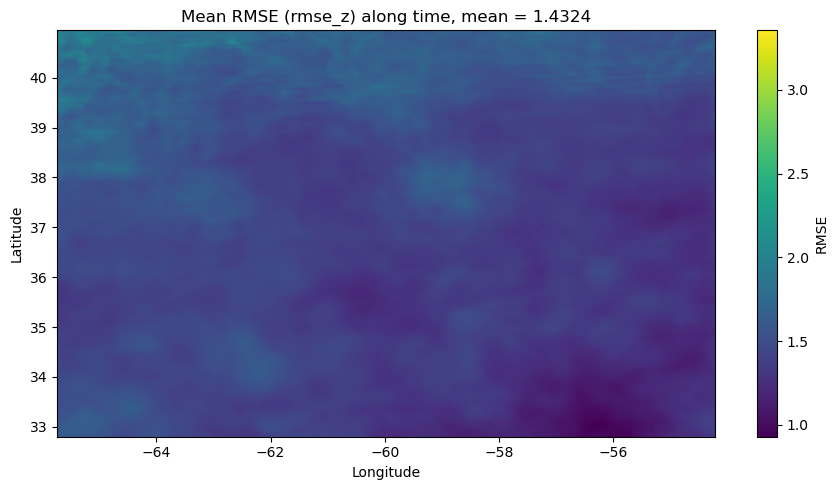

In [39]:
rmse_z_mean_time = rmse_z.mean(dim="time", skipna=True).isel(lat=slice(5, -5), lon=slice(5, -5))


lon_vals = rmse_z_mean_time["lon"].values
lat_vals = rmse_z_mean_time["lat"].values
lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)

plt.figure(figsize=(9, 5))
pcm = plt.pcolormesh(lon_grid, lat_grid, rmse_z_mean_time.values, vmax=v_max, vmin=v_min, shading="auto")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Mean RMSE (rmse_z) along time, mean = {rmse_z_mean_time.values.mean():.4f}")
cbar = plt.colorbar(pcm)
cbar.set_label("RMSE")
plt.tight_layout()
plt.show()

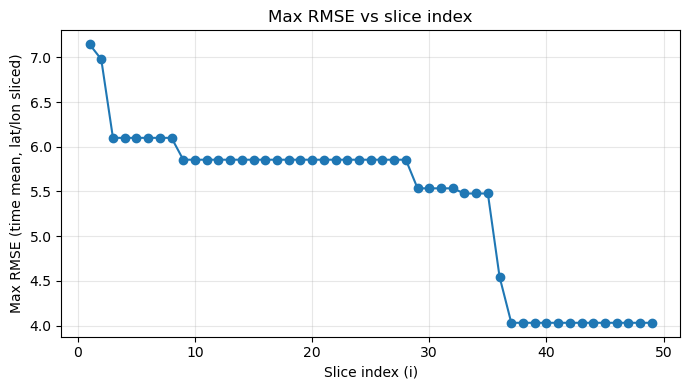

In [40]:
res = []
for i in range(1,50):
    max_rmse = rmse_z.isel(lat=slice(i, -i), lon=slice(i, -i)).max().values
    res.append(max_rmse)
    #print(f"Max RMSE for slice {i}: {max_rmse}")

plt.figure(figsize=(7, 4))
plt.plot(range(1, 50), res, marker='o')
plt.xlabel("Slice index (i)")
plt.ylabel("Max RMSE (time mean, lat/lon sliced)")
plt.title("Max RMSE vs slice index")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

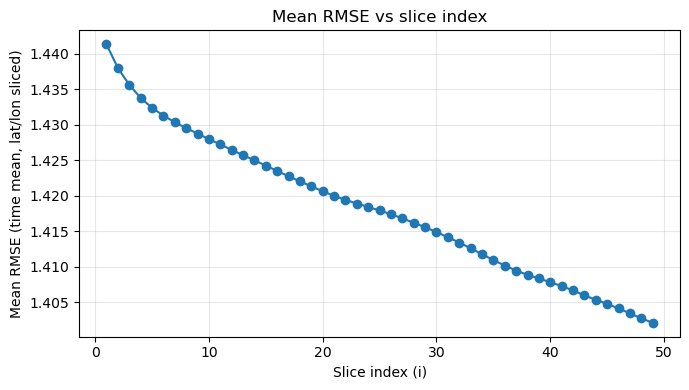

In [41]:
res = []
for i in range(1,50):
    max_rmse = rmse_z.mean(dim='time', skipna=True).isel(lat=slice(i, -i), lon=slice(i, -i)).mean().values
    res.append(max_rmse)
    #print(f"Max RMSE for slice {i}: {max_rmse}")

plt.figure(figsize=(7, 4))
plt.plot(range(1, 50), res, marker='o')
plt.xlabel("Slice index (i)")
plt.ylabel("Mean RMSE (time mean, lat/lon sliced)")
plt.title("Mean RMSE vs slice index")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

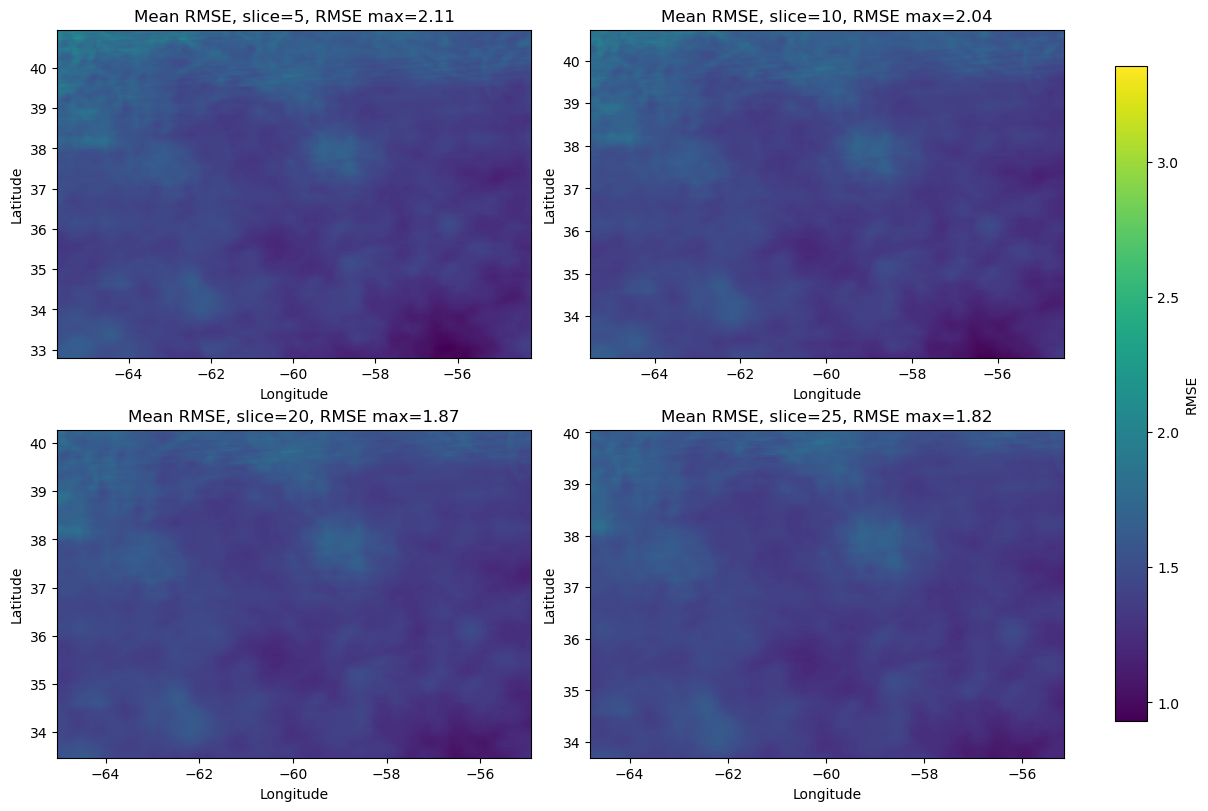

In [42]:
slice_indices = [5, 10, 20, 25]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.ravel()

pcm = None
for ax, i in zip(axes, slice_indices):
    rmse_z_mean_time = rmse_z.mean(dim="time", skipna=True).isel(
        lat=slice(i, -i), lon=slice(i, -i)
    )

    lon_vals = rmse_z_mean_time["lon"].values
    lat_vals = rmse_z_mean_time["lat"].values
    lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)

    pcm = ax.pcolormesh(
        lon_grid,
        lat_grid,
        rmse_z_mean_time.values,
        vmax=v_max,
        vmin=v_min,
        shading="auto",
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Mean RMSE, slice={i}, RMSE max={rmse_z_mean_time.max().values:.2f}")

fig.colorbar(pcm, ax=axes, label="RMSE", shrink=0.9)
plt.show()

In [43]:
import numpy as np

# Flatten rmse_z and get valid (non-NaN) values with indices
rmse_flat = rmse_z.values.ravel()
valid_mask = np.isfinite(rmse_flat)
valid_values = rmse_flat[valid_mask]
valid_indices = np.where(valid_mask)[0]

# Compute 10 decile thresholds: 0%, 11.1%, 22.2%, ..., 100%
percentiles = np.linspace(0, 100, 11)
thresholds = np.percentile(valid_values, percentiles)

# For each threshold, find the closest actual data point
selected_flat_indices = []
for thresh in thresholds:
    idx_in_valid = np.argmin(np.abs(valid_values - thresh))
    selected_flat_indices.append(valid_indices[idx_in_valid])

# Convert flat indices back to multi-dimensional coordinates
shape = rmse_z.shape
dim_names = rmse_z.dims
selected_points = []

for i, flat_idx in enumerate(selected_flat_indices):
    multi_idx = np.unravel_index(flat_idx, shape)
    point = {dim: int(idx) for dim, idx in zip(dim_names, multi_idx)}  # integer indices
    point['rmse_value'] = rmse_flat[flat_idx]
    point['percentile'] = percentiles[i]
    selected_points.append(point)

# Display results
import pandas as pd
df_deciles = pd.DataFrame(selected_points)
print(df_deciles)

    time  lat  lon  rmse_value  percentile
0      1    3  203    0.373272         0.0
1     37  106  224    1.097601        10.0
2     64   30  105    1.200063        20.0
3     32  144   32    1.275362        30.0
4     57   80  102    1.341576        40.0
5      8   57   72    1.405770        50.0
6     92  133  153    1.473796        60.0
7     48   93   81    1.552769        70.0
8     74   99   11    1.655165        80.0
9      2  103   16    1.821112        90.0
10   117  168  255    7.839458       100.0


In [44]:


# All indices where rmse-score is above or equal to a threshold
rmse_threshold = 4
rmse_flat = np.asarray(rmse_z).ravel()
rmse_valid_mask = np.isfinite(rmse_flat)

# Keep every valid point with high rmse
high_rmse_mask = rmse_valid_mask & (rmse_flat >= rmse_threshold)
high_flat_idx_rmse = np.where(high_rmse_mask)[0]
high_multi_idx_rmse = np.array(np.unravel_index(high_flat_idx_rmse, np.asarray(rmse_z).shape)).T

# Build a table with indices + values (+ coordinates if shape matches rmse_z: time, lat, lon)
high_rmse_points = []
for flat_idx, multi_idx in zip(high_flat_idx_rmse, high_multi_idx_rmse):
    row = {
        "rmse_value": float(rmse_flat[flat_idx]),
    }

    if np.asarray(rmse_z).shape == rmse_z.shape and len(multi_idx) == 3:
        t_i, lat_i, lon_i = map(int, multi_idx)
        row.update({
            "time_idx": t_i,
            "lat_idx": lat_i,
            "lon_idx": lon_i,
        })

    high_rmse_points.append(row)

df_high_rmse = pd.DataFrame(high_rmse_points).sort_values("rmse_value", ascending=False)
print(f"Number of points with rmse >= {rmse_threshold}: {len(df_high_rmse)}")
df_high_rmse

Number of points with rmse >= 4: 3617


,rmse_value,time_idx,lat_idx,lon_idx
2782,7.839458,117,168,255
2779,7.705806,117,167,255
2555,7.269823,112,160,255
2739,7.258575,116,166,255
588,7.225788,56,191,221
...,...,...,...,...
737,4.000248,60,188,204
3086,4.000103,133,157,91
1999,4.000076,93,188,105
648,4.000041,58,171,14


In [45]:


# All indices where rmse-score is above or equal to a threshold
rmse_threshold = 1
rmse_flat = np.asarray(rmse_z).ravel()
rmse_valid_mask = np.isfinite(rmse_flat)

# Keep every valid point with high rmse
high_rmse_mask = rmse_valid_mask & (rmse_flat <= rmse_threshold)
high_flat_idx_rmse = np.where(high_rmse_mask)[0]
high_multi_idx_rmse = np.array(np.unravel_index(high_flat_idx_rmse, np.asarray(rmse_z).shape)).T

# Build a table with indices + values (+ coordinates if shape matches rmse_z: time, lat, lon)
high_rmse_points = []
for flat_idx, multi_idx in zip(high_flat_idx_rmse, high_multi_idx_rmse):
    row = {
        "rmse_value": float(rmse_flat[flat_idx]),
    }

    if np.asarray(rmse_z).shape == rmse_z.shape and len(multi_idx) == 3:
        t_i, lat_i, lon_i = map(int, multi_idx)
        row.update({
            "time_idx": t_i,
            "lat_idx": lat_i,
            "lon_idx": lon_i,
        })

    high_rmse_points.append(row)

df_low_rmse = pd.DataFrame(high_rmse_points).sort_values("rmse_value", ascending=True)
print(f"Number of points with rmse <= {rmse_threshold}: {len(df_low_rmse)}")
df_low_rmse

Number of points with rmse <= 1: 366877


,rmse_value,time_idx,lat_idx,lon_idx
4722,0.373272,1,3,203
4617,0.390434,1,2,203
4721,0.395978,1,3,202
4831,0.396888,1,4,203
4830,0.408534,1,4,202
...,...,...,...,...
141934,0.999999,32,1,231
41435,1.000000,9,30,121
339135,1.000000,115,4,211
348924,1.000000,147,90,218


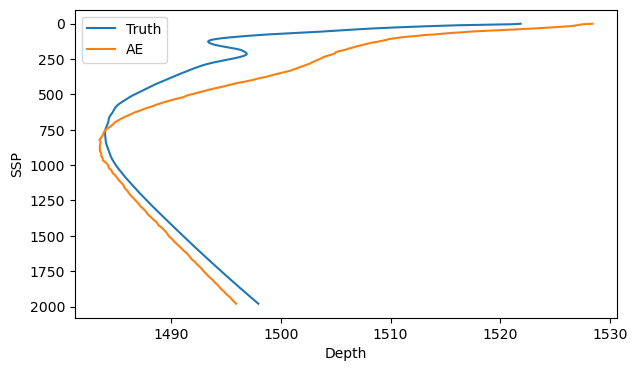

In [46]:
t,lat,lon = df_high_rmse.iloc[0][["time_idx", "lat_idx", "lon_idx"]].astype(int)
plt.figure(figsize=(7, 4))
plt.plot(ssp_truth_da.isel(time=t, lat=lat, lon=lon), depth_array, label="Truth")
plt.plot(ssp_ae_da.isel(time=t, lat=lat, lon=lon), depth_array, label="AE")
plt.xlabel("Depth")
plt.ylabel("SSP")
plt.gca().invert_yaxis()
plt.legend()
plt.show()
                                                          

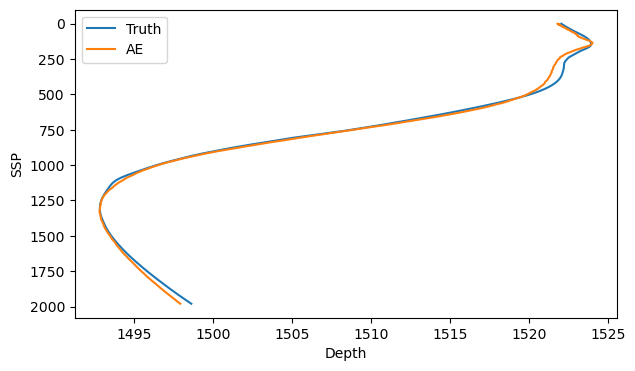

In [47]:
t,lat,lon = df_low_rmse.iloc[0][["time_idx", "lat_idx", "lon_idx"]].astype(int)
plt.figure(figsize=(7, 4))
plt.plot(ssp_truth_da.isel(time=t, lat=lat, lon=lon), depth_array, label="Truth")
plt.plot(ssp_ae_da.isel(time=t, lat=lat, lon=lon), depth_array, label="AE")
plt.xlabel("Depth")
plt.ylabel("SSP")
plt.gca().invert_yaxis()
plt.legend()
plt.show()
                                                          

In [48]:
# t_idx,lat_idx,lon_idx = df_high_rmse.iloc[0][["time_idx", "lat_idx", "lon_idx"]].astype(int)

# truth_prof = ssp_truth_da.isel(time=t_idx, lat=lat_idx, lon=lon_idx).values
# ae_prof = ssp_ae_da.isel(time=t_idx, lat=lat_idx, lon=lon_idx).values

# t=ssp_truth_da.time.values[t_idx]
# lat=ssp_truth_da.lat.values[lat_idx]
# lon=ssp_truth_da.lon.values[lon_idx]

# xr_coords = xr_truth.sel(time=t, lat=lat, lon=lon, method='nearest').coords
# t_xr,lat_xr,lon_xr = xr_coords['time'].values, xr_coords['lat'].values, xr_coords['lon'].values

# coords_140 = ssp_da_140.sel(time=t, lat=lat, lon=lon, method='nearest').coords
# t_140,lat_140,lon_140 = coords_140['time'].values, coords_140['lat'].values, coords_140['lon'].values


# print(f"Coords idx: t_idx={t_idx}, lat_idx={lat_idx}, lon_idx={lon_idx}")
# print(f"Truth time: {t.astype('datetime64[D]')}, lat: {lat}, lon: {lon}")
# print(f"xarray time: {t_xr.astype('datetime64[D]')}, lat: {lat_xr}, lon: {lon_xr}")
# print(f"140_240_dm time: {t_140.astype('datetime64[D]')}, lat: {lat_140}, lon: {lon_140}")



# xr_prof = xr_truth.sel(time=t, lat=lat, lon=lon, method='nearest').isel(z=slice(0, len(truth_prof))).values

# prof_140 = ssp_da_140.sel(time=t, lat=lat, lon=lon, method='nearest').values

# plt.figure(figsize=(7, 4))
# plt.plot(xr_prof, depth_array, lw=5, label="xarray", c='r')
# plt.plot(truth_prof, depth_array, label="Truth", c='k')
# plt.plot(prof_140, depth_array, label="140_240_dm", c='g')
# plt.plot(ae_prof, depth_array,  label="AE", c='b')
# plt.ylabel("Depth index")
# plt.xlabel("SSP value")
# plt.gca().invert_yaxis()
# plt.title(f"Worst RMSE profile at time {t_idx}, lat {lat_idx}, lon {lon_idx}")
# plt.legend()
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

In [49]:
def find_similar_profiles(data_array, target_profile, n_similar=10, method='euclidean'):
    """
    Find profiles similar to target_profile in data_array.
    
    Args:
        data_array: xr.DataArray with dims [time, z, lat, lon]
        target_profile: 1D array of shape [z]
        n_similar: number of similar profiles to return
        method: 'euclidean', 'cosine', or 'correlation'
    
    Returns:
        DataFrame with similarity scores and coordinates
    """
    import pandas as pd
    
    da = data_array.transpose('time', 'lat', 'lon', 'z')
    time, lat, lon, z = da.shape

    data_reshaped = da.values.reshape(time * lat * lon, z)
    
    # Compute similarity/distance
    if method == 'euclidean':
        scores = np.sqrt(np.sum((data_reshaped - target_profile)**2, axis=1))
        sort_ascending = True
    elif method == 'cosine':
        scores = np.array([1 - cosine(data_reshaped[i], target_profile) for i in tqdm(range(len(data_reshaped)))])
        sort_ascending = False
    elif method == 'correlation':
        scores = np.array([np.corrcoef(data_reshaped[i], target_profile)[0, 1] for i in tqdm(range(len(data_reshaped)))])
        sort_ascending = False
    
    # Get top indices
    top_idx = np.argsort(scores)[::(-1 if not sort_ascending else 1)][:n_similar]
    top_coords = np.unravel_index(top_idx, (time, lat, lon))
    
    # Create results DataFrame
    results = pd.DataFrame({
        'rank': range(1, n_similar+1),
        'time': top_coords[0],
        'lat': top_coords[1],
        'lon': top_coords[2],
        'score': scores[top_idx]
    })

    return results

# Usage
t_idx,lat_idx,lon_idx = df_high_rmse.iloc[0][["time_idx", "lat_idx", "lon_idx"]].astype(int)
t=ssp_truth_da.time.values[t_idx]
lat=ssp_truth_da.lat.values[lat_idx]
lon=ssp_truth_da.lon.values[lon_idx]

target =  ssp_truth_da.sel(time=t, lat=lat, lon=lon,method='nearest').isel(z=slice(0, 92)).values
similar = find_similar_profiles(ssp_truth_da.isel(z=slice(0,92)), target, n_similar=2000, method='correlation')
print(similar)

100%|██████████| 8060928/8060928 [04:42<00:00, 28580.05it/s]


      rank  time  lat  lon     score
0        1   117  168  255  1.000000
1        2   117  168  254  0.999956
2        3   117  167  255  0.999938
3        4   117  167  254  0.999892
4        5   118  168  253  0.999682
...    ...   ...  ...  ...       ...
1995  1996   133  183  201  0.981193
1996  1997   145  188  180  0.981192
1997  1998   124  103  159  0.981186
1998  1999    47  132   24  0.981182
1999  2000   120  103  163  0.981179

[2000 rows x 5 columns]


Original coords:
Original Coords idx: t_idx=117, lat_idx=168, lon_idx=255
Similar Coords idx: t_idx=126, lat_idx=176, lon_idx=227


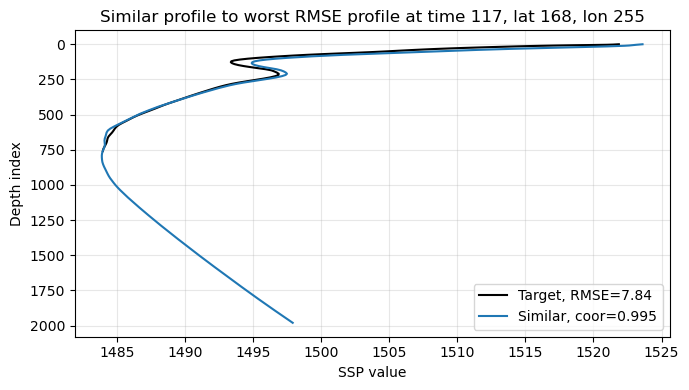

In [50]:

i=100

t_idx_2,lat_idx_2,lon_idx_2 = similar.iloc[i][["time", "lat", "lon"]].astype(int)
similar_prof = ssp_truth_da.isel(time=t_idx_2, lat=lat_idx_2, lon=lon_idx_2).values

print("Original coords:")
print(f"Original Coords idx: t_idx={t_idx}, lat_idx={lat_idx}, lon_idx={lon_idx}")
print(f"Similar Coords idx: t_idx={t_idx_2}, lat_idx={lat_idx_2}, lon_idx={lon_idx_2}")



#xr_prof = xr_truth.sel(time=t, lat=lat, lon=lon, method='nearest').isel(z=slice(0, len(truth_prof))).values


plt.figure(figsize=(7, 4))
plt.plot(target, depth_array[:92], c='k', label=f"Target, RMSE={df_high_rmse.iloc[0]['rmse_value']:.2f}")
plt.plot(similar_prof, depth_array, alpha=1, label=f"Similar, coor={similar.iloc[i]['score']:.3f}")

plt.ylabel("Depth index")
plt.xlabel("SSP value")
plt.gca().invert_yaxis()
plt.title(f"Similar profile to worst RMSE profile at time {t_idx}, lat {lat_idx}, lon {lon_idx}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

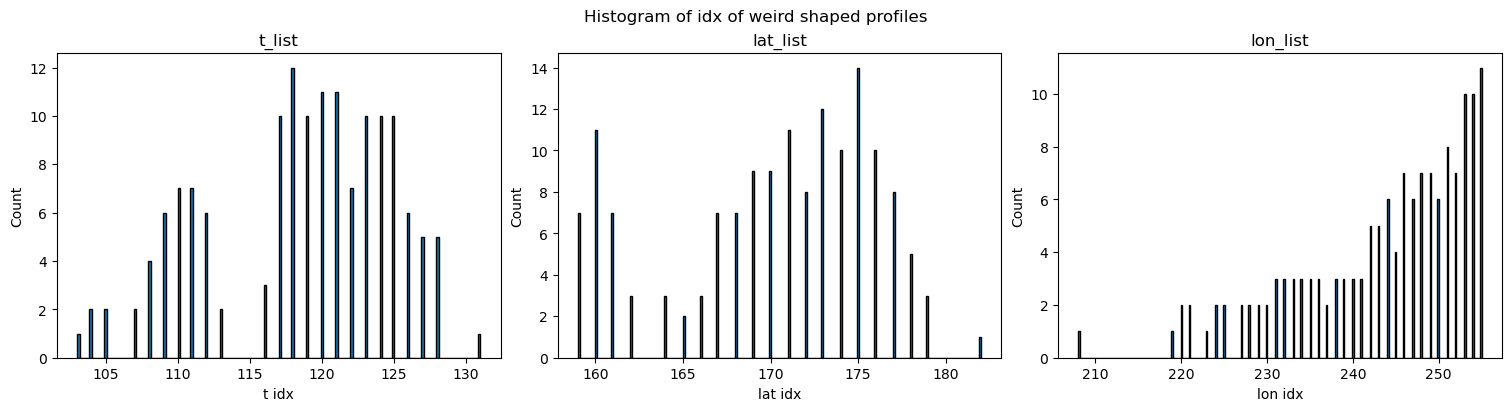

In [51]:
t_list = similar["time"][:150].values
lat_list = similar["lat"][:150].values
lon_list = similar["lon"][:150].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].hist(t_list, bins=len(ssp_truth_da.time), edgecolor="black")
axes[0].set_xlabel("t idx")
axes[0].set_ylabel("Count")
axes[0].set_title("t_list")

axes[1].hist(lat_list, bins=len(ssp_truth_da.lat), edgecolor="black")
axes[1].set_xlabel("lat idx")
axes[1].set_ylabel("Count")
axes[1].set_title("lat_list")

axes[2].hist(lon_list, bins=len(ssp_truth_da.lon), edgecolor="black")
axes[2].set_xlabel("lon idx")
axes[2].set_ylabel("Count")
axes[2].set_title("lon_list")

fig.suptitle("Histogram of idx of weird shaped profiles")
plt.show()

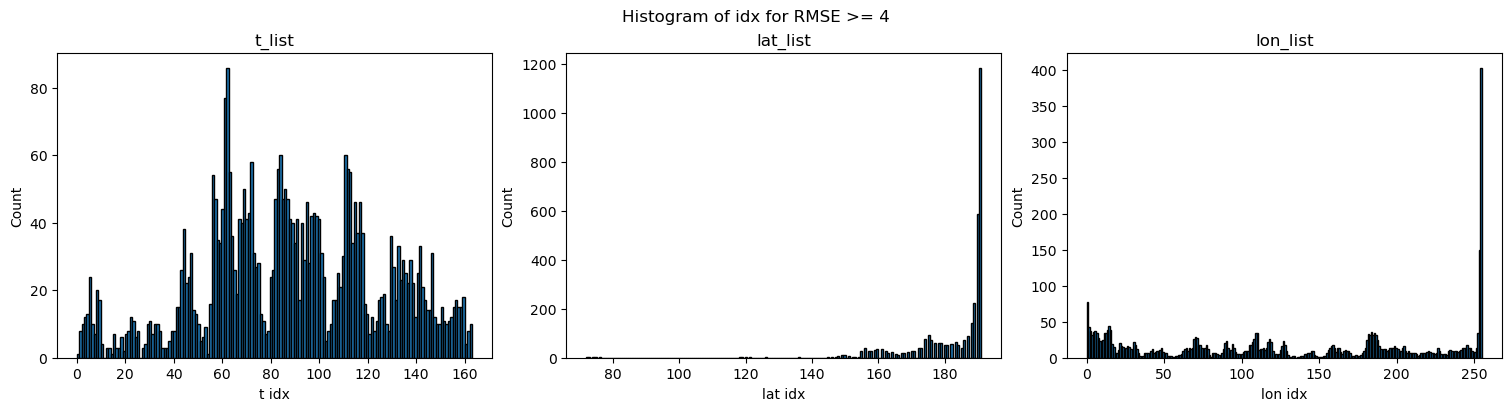

In [52]:
t_list = df_high_rmse["time_idx"].values
lat_list = df_high_rmse["lat_idx"].values
lon_list = df_high_rmse["lon_idx"].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].hist(t_list, bins=len(ssp_truth_da.time), edgecolor="black")
axes[0].set_xlabel("t idx")
axes[0].set_ylabel("Count")
axes[0].set_title("t_list")

axes[1].hist(lat_list, bins=len(ssp_truth_da.lat), edgecolor="black")
axes[1].set_xlabel("lat idx")
axes[1].set_ylabel("Count")
axes[1].set_title("lat_list")

axes[2].hist(lon_list, bins=len(ssp_truth_da.lon), edgecolor="black")
axes[2].set_xlabel("lon idx")
axes[2].set_ylabel("Count")
axes[2].set_title("lon_list")

fig.suptitle("Histogram of idx for RMSE >= 4")
plt.show()

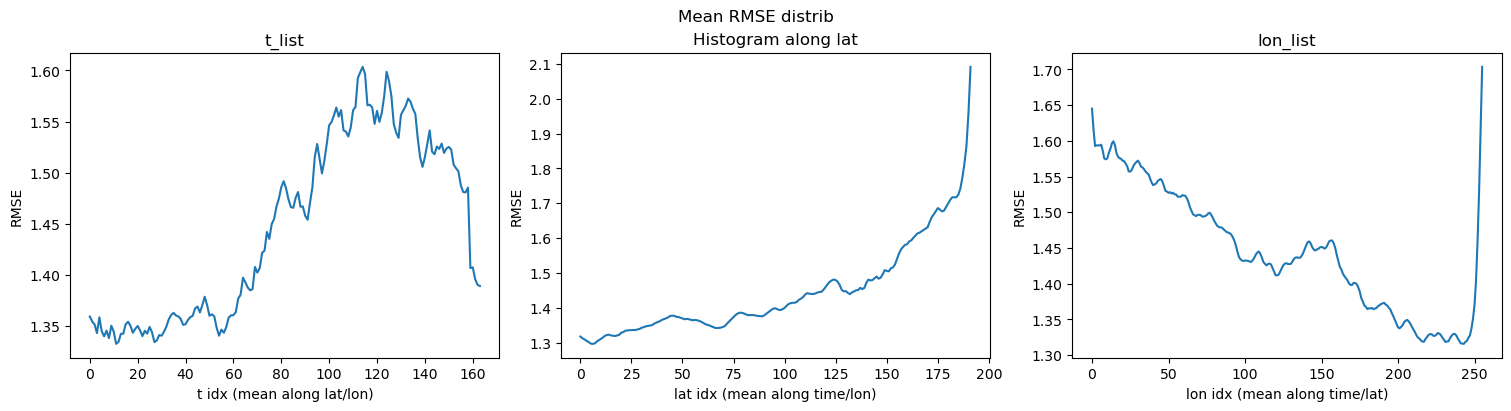

In [53]:
t_mean = rmse_z.mean(dim=("lat","lon"), skipna=True).values
lat_mean = rmse_z.mean(dim=("time","lon"), skipna=True).values
lon_mean = rmse_z.mean(dim=("time","lat"), skipna=True).values 

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].plot(np.arange(len(t_mean)), t_mean)
axes[0].set_xlabel("t idx (mean along lat/lon)")
axes[0].set_ylabel("RMSE")
axes[0].set_title("t_list")

axes[1].plot(np.arange(len(lat_mean)), lat_mean)
axes[1].set_xlabel("lat idx (mean along time/lon)")
axes[1].set_ylabel("RMSE")
axes[1].set_title("Histogram along lat")

axes[2].plot(np.arange(len(lon_mean)), lon_mean)
axes[2].set_xlabel("lon idx (mean along time/lat)")
axes[2].set_ylabel("RMSE")
axes[2].set_title("lon_list")

fig.suptitle("Mean RMSE distrib")
plt.show()

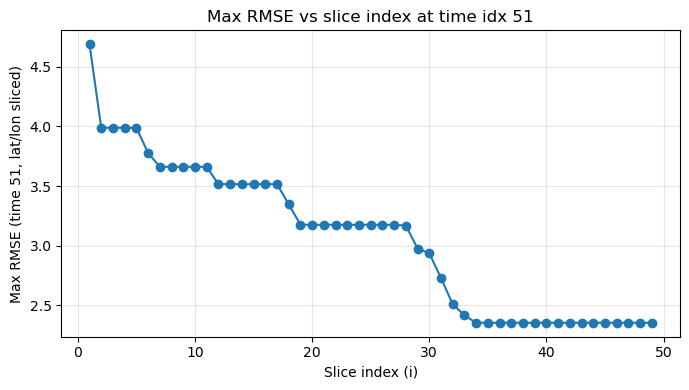

In [54]:
res = []
t = 51
for i in range(1,50):
    max_rmse = rmse_z.isel(time=t,lat=slice(i, -i), lon=slice(i, -i)).max().values
    res.append(max_rmse)
    #print(f"Max RMSE for slice {i}: {max_rmse}")

plt.figure(figsize=(7, 4))
plt.plot(range(1, 50), res, marker='o')
plt.xlabel("Slice index (i)")
plt.ylabel("Max RMSE (time 51, lat/lon sliced)")
plt.title("Max RMSE vs slice index at time idx 51")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

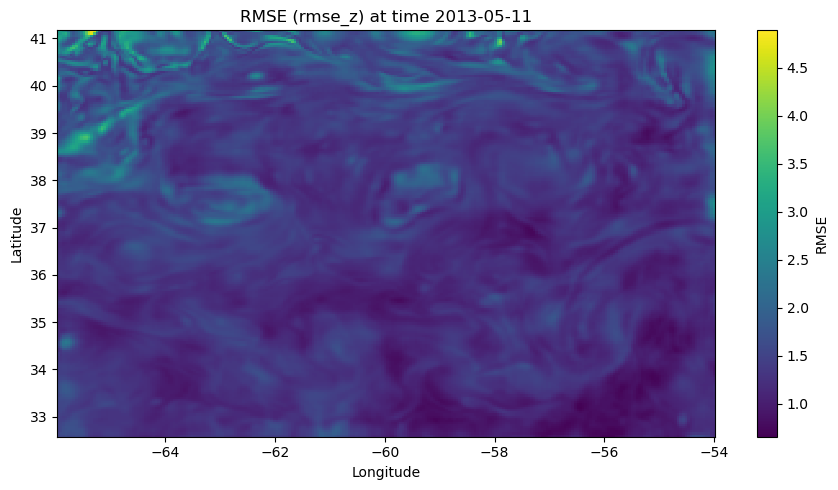

In [55]:
t=51
rmse_z_mean_time = rmse_z.isel(time=t)


lon_vals = rmse_z_mean_time["lon"].values
lat_vals = rmse_z_mean_time["lat"].values
lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)

plt.figure(figsize=(9, 5))
pcm = plt.pcolormesh(lon_grid, lat_grid, rmse_z_mean_time.values, shading="auto")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"RMSE (rmse_z) at time {ssp_da.time[t].values.astype('datetime64[D]')}")
cbar = plt.colorbar(pcm)
cbar.set_label("RMSE")
plt.tight_layout()
plt.show()

In [56]:
import xarray as xr

xr_truth = xr.open_dataarray("/Odyssey/public/enatl60/celerity/eNATL60_BLB002_sound_speed_regrid_0_botm.nc")
xr_truth

<xarray.DataArray 'celerity' (time: 365, z: 300, lat: 240, lon: 240)> Size: 50GB
[6307200000 values with dtype=float64]
Coordinates:
  * lon      (lon) float64 2kB -65.95 -65.9 -65.85 -65.8 ... -54.1 -54.05 -54.0
  * lat      (lat) float64 2kB 32.0 32.05 32.1 32.15 ... 43.8 43.85 43.9 43.95
  * z        (z) float64 2kB 0.4805 1.559 2.794 ... 5.975e+03 6.025e+03
  * time     (time) datetime64[ns] 3kB 2009-07-01T12:00:00 ... 2010-06-30T12:...

In [ ]:
# cr = list(data_dict[k].keys())[0]
# (t_idx,lat_idx,lon_idx),truth_prof, ae_prof =  data_dict[k][cr]['RMSE']['worst']['t_lat_lon']

# t=ssp_truth_da.time.values[t_idx]
# lat=ssp_truth_da.lat.values[lat_idx]
# lon=ssp_truth_da.lon.values[lon_idx]

# # xr_coords = xr_truth.sel(time=t, lat=lat, lon=lon, method='nearest').coords
# # t_xr,lat_xr,lon_xr = xr_coords['time'].values, xr_coords['lat'].values, xr_coords['lon'].values

# # coords_140 = ssp_da_140.sel(time=t, lat=lat, lon=lon, method='nearest').coords
# # t_140,lat_140,lon_140 = coords_140['time'].values, coords_140['lat'].values, coords_140['lon'].values


# print(f"Coords idx: t_idx={t_idx}, lat_idx={lat_idx}, lon_idx={lon_idx}")
# print(f"Truth time: {t.astype('datetime64[D]')}, lat: {lat}, lon: {lon}")
# print(f"xarray time: {t_xr.astype('datetime64[D]')}, lat: {lat_xr}, lon: {lon_xr}")
# print(f"140_240_dm time: {t_140.astype('datetime64[D]')}, lat: {lat_140}, lon: {lon_140}")



# xr_prof = xr_truth.sel(time=t, lat=lat, lon=lon, method='nearest').isel(z=slice(0, len(truth_prof))).values

# prof_140 = ssp_da_140.sel(time=t, lat=lat, lon=lon, method='nearest').values

# plt.figure(figsize=(7, 4))
# plt.plot(truth_prof, depth_array, label="Truth", c='k')
# # plt.plot(xr_prof, depth_array, label="xarray", c='r')
# # plt.plot(prof_140, depth_array, label="140_240_dm", c='g')
# plt.plot(ae_prof, depth_array,  label="AE", c='b')
# plt.ylabel("Depth index")
# plt.xlabel("SSP value")
# plt.gca().invert_yaxis()
# plt.title(f"Worst RMSE profile at time {t_idx}, lat {lat_idx}, lon {lon_idx}")
# plt.legend()
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

KeyError: 'test_enatl_natl_mse_fixed_weight_loss_64_96_1.0_CR_10000.0_enatl_natl__mean_std_20260402_154931_best_checkpoint_bpp_loss'

In [ ]:
# cr = list(data_dict[k].keys())[0]
# (t,lat,lon),truth_prof, ae_prof =  data_dict[k][cr]['RMSE']['best']['t_lat_lon']

# plt.figure(figsize=(7, 4))
# plt.plot(truth_prof, depth_array, label="Truth", c='k')
# plt.plot(ae_prof, depth_array,  label="AE", c='b')
# plt.ylabel("Depth index")
# plt.xlabel("SSP value")
# plt.gca().invert_yaxis()
# plt.title(f"Best RMSE profile at time {t}, lat {lat}, lon {lon}")
# plt.legend()
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

KeyError: 'test_enatl_natl_mse_fixed_weight_loss_64_96_1.0_CR_10000.0_enatl_natl__mean_std_20260402_154931_best_checkpoint_bpp_loss'

In [60]:
metric = "RMSE"
t_list,lat_list, lon_list = [], [], []
for k in data_dict.keys():
    #print(f"Key: {k}")
    for cr in data_dict[k].keys():
        #print(f"  CR: {cr}")
        t,lat,lon = data_dict[k][cr][metric]['worst']['t_lat_lon'][0]
        t_list.append(t)
        lat_list.append(lat)
        lon_list.append(lon)


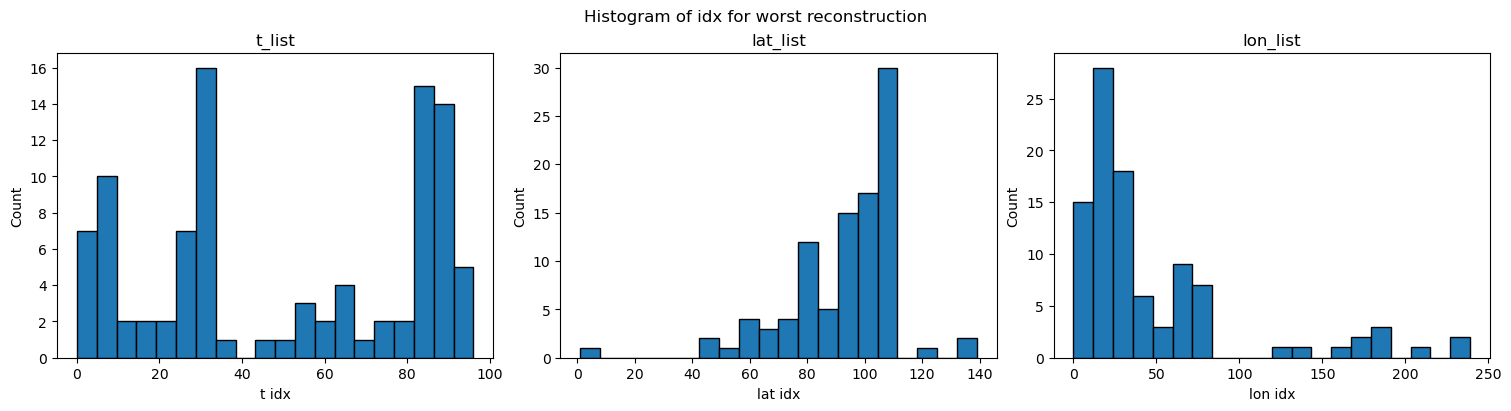

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].hist(t_list, bins=20, edgecolor="black")
axes[0].set_xlabel("t idx")
axes[0].set_ylabel("Count")
axes[0].set_title("t_list")

axes[1].hist(lat_list, bins=20, edgecolor="black")
axes[1].set_xlabel("lat idx")
axes[1].set_ylabel("Count")
axes[1].set_title("lat_list")

axes[2].hist(lon_list, bins=20, edgecolor="black")
axes[2].set_xlabel("lon idx")
axes[2].set_ylabel("Count")
axes[2].set_title("lon_list")

fig.suptitle("Histogram of idx for worst reconstruction")
plt.show()

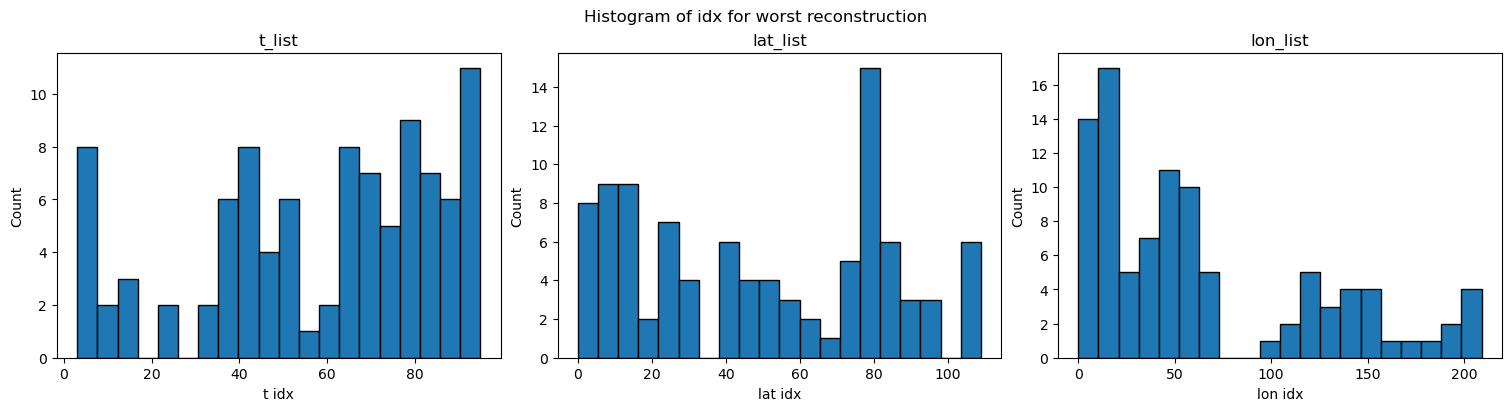

In [62]:
metric = "RMSE"
t_list,lat_list, lon_list = [], [], []
for k in data_dict.keys():
    #print(f"Key: {k}")
    for cr in data_dict[k].keys():
        #print(f"  CR: {cr}")
        t,lat,lon = data_dict[k][cr][metric]['best']['t_lat_lon'][0]
        t_list.append(t)
        lat_list.append(lat)
        lon_list.append(lon)


fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].hist(t_list, bins=20, edgecolor="black")
axes[0].set_xlabel("t idx")
axes[0].set_ylabel("Count")
axes[0].set_title("t_list")

axes[1].hist(lat_list, bins=20, edgecolor="black")
axes[1].set_xlabel("lat idx")
axes[1].set_ylabel("Count")
axes[1].set_title("lat_list")

axes[2].hist(lon_list, bins=20, edgecolor="black")
axes[2].set_xlabel("lon idx")
axes[2].set_ylabel("Count")
axes[2].set_title("lon_list")

fig.suptitle("Histogram of idx for worst reconstruction")
plt.show()

# F1 score

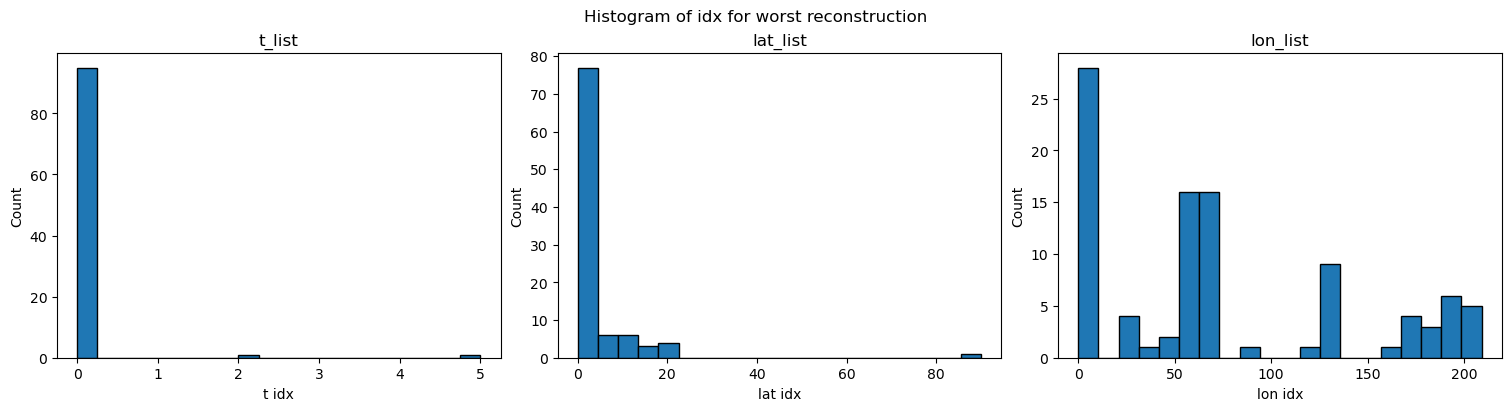

In [63]:
metric = "F1_score"
t_list,lat_list, lon_list = [], [], []
for k in data_dict.keys():
    #print(f"Key: {k}")
    for cr in data_dict[k].keys():
        #print(f"  CR: {cr}")
        t,lat,lon = data_dict[k][cr][metric]['worst']['t_lat_lon'][0]
        t_list.append(t)
        lat_list.append(lat)
        lon_list.append(lon)


fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].hist(t_list, bins=20, edgecolor="black")
axes[0].set_xlabel("t idx")
axes[0].set_ylabel("Count")
axes[0].set_title("t_list")

axes[1].hist(lat_list, bins=20, edgecolor="black")
axes[1].set_xlabel("lat idx")
axes[1].set_ylabel("Count")
axes[1].set_title("lat_list")

axes[2].hist(lon_list, bins=20, edgecolor="black")
axes[2].set_xlabel("lon idx")
axes[2].set_ylabel("Count")
axes[2].set_title("lon_list")

fig.suptitle("Histogram of idx for worst reconstruction")
plt.show()

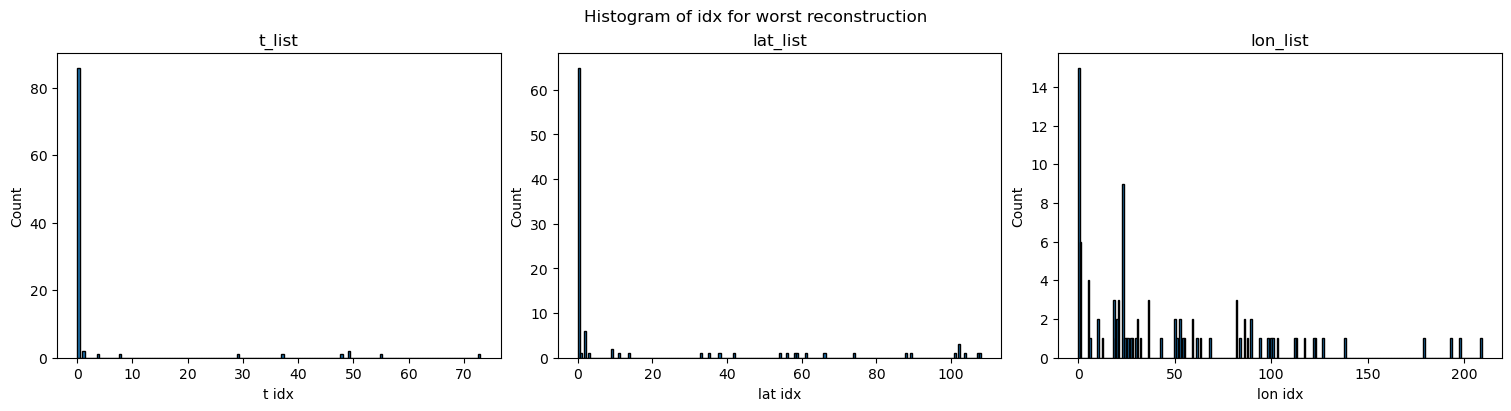

In [64]:
metric = "F1_score"
t_list,lat_list, lon_list = [], [], []
for k in data_dict.keys():
    #print(f"Key: {k}")
    for cr in data_dict[k].keys():
        #print(f"  CR: {cr}")
        t,lat,lon = data_dict[k][cr][metric]['best']['t_lat_lon'][0]
        t_list.append(t)
        lat_list.append(lat)
        lon_list.append(lon)


fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].hist(t_list, bins=len(ssp_truth_da.time), edgecolor="black")
axes[0].set_xlabel("t idx")
axes[0].set_ylabel("Count")
axes[0].set_title("t_list")

axes[1].hist(lat_list, bins=len(ssp_truth_da.lat), edgecolor="black")
axes[1].set_xlabel("lat idx")
axes[1].set_ylabel("Count")
axes[1].set_title("lat_list")

axes[2].hist(lon_list, bins=len(ssp_truth_da.lon), edgecolor="black")
axes[2].set_xlabel("lon idx")
axes[2].set_ylabel("Count")
axes[2].set_title("lon_list")

fig.suptitle("Histogram of idx for worst reconstruction")
plt.show()

In [65]:
min_max_idx_truth = get_min_max_idx(ssp_truth_da, pad=False)
min_max_idx_ae = get_min_max_idx(ssp_ae_da, pad=False)

In [66]:

F1_score = get_f1_score(min_max_idx_truth, min_max_idx_ae)
f1_score = np.mean(F1_score)

/tmp/ipykernel_2604753/2648127300.py:28: RuntimeWarning: invalid value encountered in divide
  recall_score = np.where(recall_den == 0, 0, num_true_positives / recall_den)
/tmp/ipykernel_2604753/2648127300.py:30: RuntimeWarning: invalid value encountered in divide
  f1_score = np.where(sum_scores == 0, 0, 2 * (precision_score * recall_score) / sum_scores)


In [67]:
# All indices where F1-score is below or equal to a threshold
f1_threshold = 0
f1_flat = np.asarray(F1_score).ravel()
f1_valid_mask = np.isfinite(f1_flat)

# Keep every valid point with low F1
low_f1_mask = f1_valid_mask & (f1_flat <= f1_threshold)
low_flat_idx_f1 = np.where(low_f1_mask)[0]
low_multi_idx_f1 = np.array(np.unravel_index(low_flat_idx_f1, np.asarray(F1_score).shape)).T

# Build a table with indices + values (+ coordinates if shape matches rmse_z: time, lat, lon)
low_f1_points = []
for flat_idx, multi_idx in zip(low_flat_idx_f1, low_multi_idx_f1):
    row = {
        "f1_value": float(f1_flat[flat_idx]),
    }

    if np.asarray(F1_score).shape == rmse_z.shape and len(multi_idx) == 3:
        t_i, lat_i, lon_i = map(int, multi_idx)
        row.update({
            "time_idx": t_i,
            "lat_idx": lat_i,
            "lon_idx": lon_i,
        })

    low_f1_points.append(row)

df_low_f1 = pd.DataFrame(low_f1_points).sort_values("f1_value")
print(f"Number of points with F1 <= {f1_threshold}: {len(df_low_f1)}")
df_low_f1

Number of points with F1 <= 0: 35221


,f1_value,time_idx,lat_idx,lon_idx
0,0.0,0,0,159
1,0.0,0,0,162
2,0.0,0,0,163
3,0.0,0,0,165
4,0.0,0,0,171
...,...,...,...,...
35216,0.0,163,181,255
35217,0.0,163,183,59
35218,0.0,163,184,60
35219,0.0,163,186,62


In [68]:
# 100 best (highest) F1-score indices
f1_flat = np.asarray(F1_score).ravel()
f1_valid_mask = np.isfinite(f1_flat)
f1_valid_flat_idx = np.where(f1_valid_mask)[0]

top_k_f1 = 100
best_pos_in_valid = np.argsort(f1_flat[f1_valid_mask])[-top_k_f1:][::-1]  # descending = best
best_flat_idx_f1 = f1_valid_flat_idx[best_pos_in_valid]
best_multi_idx_f1 = np.array(np.unravel_index(best_flat_idx_f1, np.asarray(F1_score).shape)).T

# Build a table with indices + values (+ coordinates if shape matches rmse_z: time, lat, lon)
best_f1_points = []
for rank, (flat_idx, multi_idx) in enumerate(zip(best_flat_idx_f1, best_multi_idx_f1), start=1):
    row = {
        "rank": rank,
        "f1_value": float(f1_flat[flat_idx]),
    }
    # for d, idx in enumerate(multi_idx):
    #     row[f"dim{d}_idx"] = int(idx)

    if np.asarray(F1_score).shape == rmse_z.shape and len(multi_idx) == 3:
        t_i, lat_i, lon_i = map(int, multi_idx)
        row.update({
            "time_idx": t_i,
            "lat_idx": lat_i,
            "lon_idx": lon_i,
        })

    best_f1_points.append(row)

df_best100_f1 = pd.DataFrame(best_f1_points)
df_best100_f1

,rank,f1_value,time_idx,lat_idx,lon_idx
0,1,1.0,104,167,119
1,2,1.0,104,167,238
2,3,1.0,104,167,217
3,4,1.0,104,167,231
4,5,1.0,104,167,230
...,...,...,...,...,...
95,96,1.0,138,150,58
96,97,1.0,149,151,25
97,98,1.0,149,151,22
98,99,1.0,149,150,226


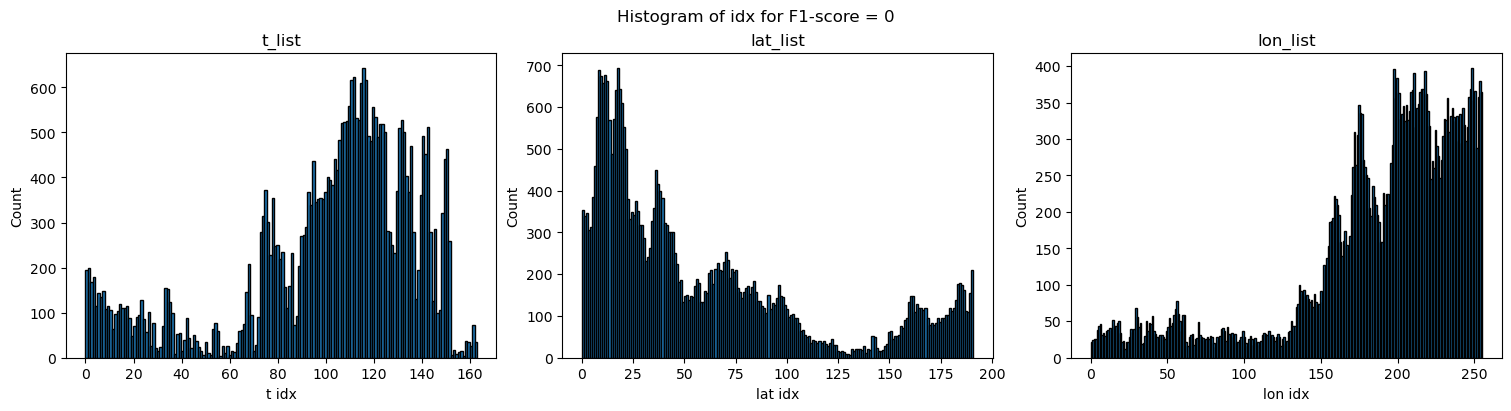

In [69]:
t_list = df_low_f1["time_idx"].values
lat_list = df_low_f1["lat_idx"].values
lon_list = df_low_f1["lon_idx"].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].hist(t_list, bins=len(ssp_truth_da.time), edgecolor="black")
axes[0].set_xlabel("t idx")
axes[0].set_ylabel("Count")
axes[0].set_title("t_list")

axes[1].hist(lat_list, bins=len(ssp_truth_da.lat), edgecolor="black")
axes[1].set_xlabel("lat idx")
axes[1].set_ylabel("Count")
axes[1].set_title("lat_list")

axes[2].hist(lon_list, bins=len(ssp_truth_da.lon), edgecolor="black")
axes[2].set_xlabel("lon idx")
axes[2].set_ylabel("Count")
axes[2].set_title("lon_list")

fig.suptitle("Histogram of idx for F1-score = 0")
plt.show()

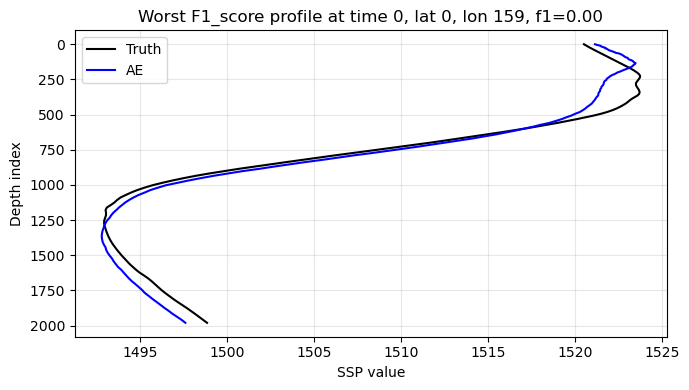

In [70]:
# cr = list(data_dict[k].keys())[0]
# (t,lat,lon),truth_prof, ae_prof =  data_dict[k][cr]['RMSE']['worst']['t_lat_lon']

t,lat,lon = df_low_f1.iloc[0][["time_idx", "lat_idx", "lon_idx"]].astype(int).values
truth_prof = ssp_truth_da.isel(time=t, lat=lat, lon=lon).values
ae_prof = ssp_ae_da.isel(time=t, lat=lat, lon=lon).values

plt.figure(figsize=(7, 4))
plt.plot(truth_prof, depth_array, label="Truth", c='k')
plt.plot(ae_prof, depth_array,  label="AE", c='b')
plt.ylabel("Depth index")
plt.xlabel("SSP value")
plt.gca().invert_yaxis()
plt.title(f"Worst F1_score profile at time {t}, lat {lat}, lon {lon}, f1={df_low_f1.iloc[0]['f1_value']:.2f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [71]:
# best_f1 = 0
res = []
best_w = 0.1
# for w in tqdm([0.09, 0.1, 0.11]):

#     b, a = butter(N=2, Wn=w, btype='low', analog=False)
#     filt_ae = filtfilt(b, a, ssp_ae_da, axis=1).astype(ssp_ae_da.dtype)
#     #filt_ssp_ae_da = ssp_ae_da.copy(data=filt_ae)
#     min_max_idx_ae = get_min_max_idx(filt_ae, pad=False)
#     F1_score = get_f1_score(min_max_idx_truth, min_max_idx_ae)
#     f1_score = np.mean(F1_score)
#     res.append((w, f1_score))

#     if f1_score > best_f1:
#         best_f1 = f1_score
#         best_w = w

b, a = butter(N=2, Wn=best_w, btype='low', analog=False)
filt_ae = filtfilt(b, a, ssp_ae_da, axis=1).astype(ssp_ae_da.dtype)
min_max_idx_ae = get_min_max_idx(filt_ae, pad=False)
filt_F1_score = get_f1_score(min_max_idx_truth, min_max_idx_ae)
filt_f1_score = np.mean(filt_F1_score)

/tmp/ipykernel_2604753/2648127300.py:28: RuntimeWarning: invalid value encountered in divide
  recall_score = np.where(recall_den == 0, 0, num_true_positives / recall_den)
/tmp/ipykernel_2604753/2648127300.py:30: RuntimeWarning: invalid value encountered in divide
  f1_score = np.where(sum_scores == 0, 0, 2 * (precision_score * recall_score) / sum_scores)


In [72]:
res

[]

In [73]:
print(f1_score)
print(filt_f1_score)

0.6273312786220187
0.5973260229198808


In [74]:
# All indices where F1-score is below or equal to a threshold
f1_threshold = 0
f1_flat = np.asarray(filt_F1_score).ravel()
f1_valid_mask = np.isfinite(f1_flat)

# Keep every valid point with low F1
low_f1_mask = f1_valid_mask & (f1_flat <= f1_threshold)
low_flat_idx_f1 = np.where(low_f1_mask)[0]
low_multi_idx_f1 = np.array(np.unravel_index(low_flat_idx_f1, np.asarray(F1_score).shape)).T

# Build a table with indices + values (+ coordinates if shape matches rmse_z: time, lat, lon)
low_f1_points = []
for flat_idx, multi_idx in zip(low_flat_idx_f1, low_multi_idx_f1):
    row = {
        "f1_value": float(f1_flat[flat_idx]),
    }

    if np.asarray(F1_score).shape == rmse_z.shape and len(multi_idx) == 3:
        t_i, lat_i, lon_i = map(int, multi_idx)
        row.update({
            "time_idx": t_i,
            "lat_idx": lat_i,
            "lon_idx": lon_i,
        })

    low_f1_points.append(row)

filt_df_low_f1 = pd.DataFrame(low_f1_points).sort_values("f1_value")
print(f"Number of points with F1 <= {f1_threshold}: {len(df_low_f1)}")
filt_df_low_f1

Number of points with F1 <= 0: 35221


,f1_value,time_idx,lat_idx,lon_idx
0,0.0,0,0,157
1,0.0,0,0,158
2,0.0,0,0,159
3,0.0,0,0,160
4,0.0,0,0,161
...,...,...,...,...
77913,0.0,163,191,87
77914,0.0,163,191,88
77915,0.0,163,191,89
77916,0.0,163,191,192


In [75]:
# All indices where F1-score is above or equal to a threshold
f1_threshold = 1.0
f1_flat = np.asarray(filt_F1_score).ravel()
f1_valid_mask = np.isfinite(f1_flat)

# Keep every valid point with high F1
high_f1_mask = f1_valid_mask & (f1_flat >= f1_threshold)
high_flat_idx_f1 = np.where(high_f1_mask)[0]
high_multi_idx_f1 = np.array(np.unravel_index(high_flat_idx_f1, np.asarray(filt_F1_score).shape)).T

# Build a table with indices + values (+ coordinates if shape matches rmse_z: time, lat, lon)
high_f1_points = []
for flat_idx, multi_idx in zip(high_flat_idx_f1, high_multi_idx_f1):
    row = {
        "f1_value": float(f1_flat[flat_idx]),
    }

    if np.asarray(filt_F1_score).shape == rmse_z.shape and len(multi_idx) == 3:
        t_i, lat_i, lon_i = map(int, multi_idx)
        row.update({
            "time_idx": t_i,
            "lat_idx": lat_i,
            "lon_idx": lon_i,
        })

    high_f1_points.append(row)

filt_df_high_f1 = pd.DataFrame(high_f1_points).sort_values("f1_value", ascending=False)
print(f"Number of points with F1 >= {f1_threshold}: {len(filt_df_high_f1)}")
filt_df_high_f1

Number of points with F1 >= 1.0: 884051


,f1_value,time_idx,lat_idx,lon_idx
0,1.0,0,0,95
1,1.0,0,0,112
2,1.0,0,0,179
3,1.0,0,1,96
4,1.0,0,1,109
...,...,...,...,...
884046,1.0,163,191,210
884047,1.0,163,191,211
884048,1.0,163,191,212
884049,1.0,163,191,225


In [76]:
# All indices where F1-score is above or equal to a threshold
f1_threshold = 1.0
f1_flat = np.asarray(F1_score).ravel()
f1_valid_mask = np.isfinite(f1_flat)

# Keep every valid point with high F1
high_f1_mask = f1_valid_mask & (f1_flat >= f1_threshold)
high_flat_idx_f1 = np.where(high_f1_mask)[0]
high_multi_idx_f1 = np.array(np.unravel_index(high_flat_idx_f1, np.asarray(filt_F1_score).shape)).T

# Build a table with indices + values (+ coordinates if shape matches rmse_z: time, lat, lon)
high_f1_points = []
for flat_idx, multi_idx in zip(high_flat_idx_f1, high_multi_idx_f1):
    row = {
        "f1_value": float(f1_flat[flat_idx]),
    }

    if np.asarray(F1_score).shape == rmse_z.shape and len(multi_idx) == 3:
        t_i, lat_i, lon_i = map(int, multi_idx)
        row.update({
            "time_idx": t_i,
            "lat_idx": lat_i,
            "lon_idx": lon_i,
        })

    high_f1_points.append(row)

df_high_f1 = pd.DataFrame(high_f1_points).sort_values("f1_value", ascending=False)
print(f"Number of points with F1 >= {f1_threshold}: {len(filt_df_high_f1)}")
df_high_f1

Number of points with F1 >= 1.0: 884051


,f1_value,time_idx,lat_idx,lon_idx
0,1.0,0,7,218
1,1.0,0,10,216
2,1.0,0,18,244
3,1.0,0,18,250
4,1.0,0,18,253
...,...,...,...,...
330850,1.0,163,188,138
330851,1.0,163,188,244
330852,1.0,163,189,137
330853,1.0,163,189,244


In [77]:
print(len(filt_df_low_f1), len(df_low_f1))
print(len(filt_df_high_f1), len(df_high_f1))

77918 35221
884051 330855


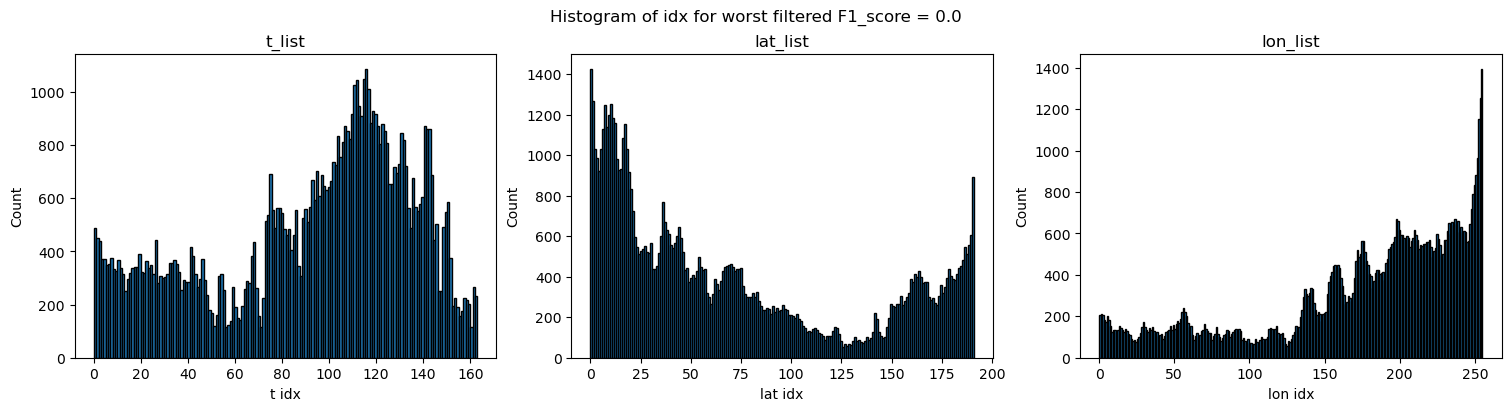

In [78]:
t_list = filt_df_low_f1["time_idx"].values
lat_list = filt_df_low_f1["lat_idx"].values
lon_list = filt_df_low_f1["lon_idx"].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].hist(t_list, bins=len(ssp_truth_da.time), edgecolor="black")
axes[0].set_xlabel("t idx")
axes[0].set_ylabel("Count")
axes[0].set_title("t_list")

axes[1].hist(lat_list, bins=len(ssp_truth_da.lat), edgecolor="black")
axes[1].set_xlabel("lat idx")
axes[1].set_ylabel("Count")
axes[1].set_title("lat_list")

axes[2].hist(lon_list, bins=len(ssp_truth_da.lon), edgecolor="black")
axes[2].set_xlabel("lon idx")
axes[2].set_ylabel("Count")
axes[2].set_title("lon_list")

fig.suptitle("Histogram of idx for worst filtered F1_score = 0.0")
plt.show()

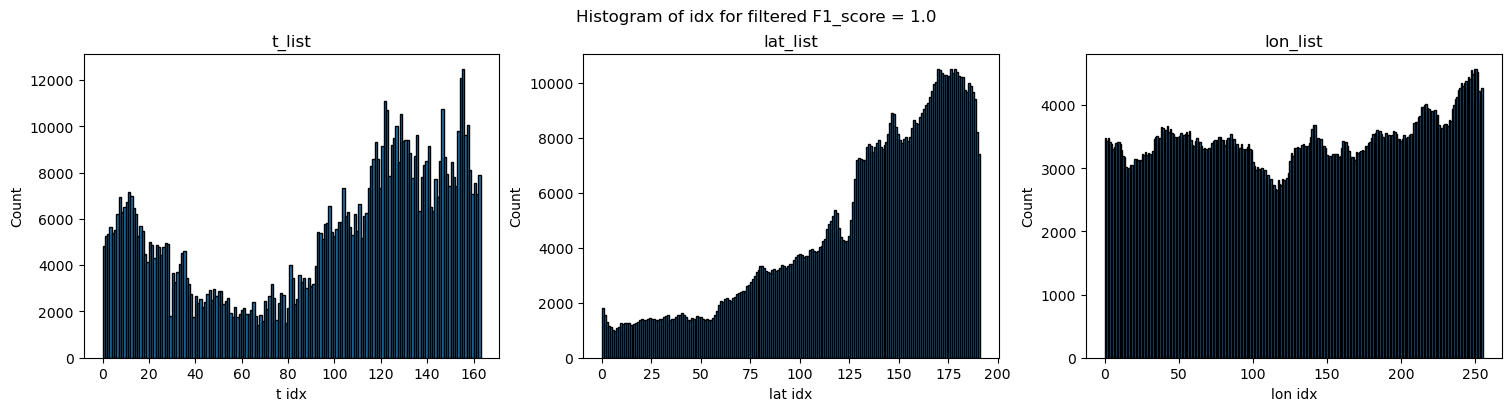

In [79]:
t_list = filt_df_high_f1["time_idx"].values
lat_list = filt_df_high_f1["lat_idx"].values
lon_list = filt_df_high_f1["lon_idx"].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].hist(t_list, bins=len(ssp_truth_da.time), edgecolor="black")
axes[0].set_xlabel("t idx")
axes[0].set_ylabel("Count")
axes[0].set_title("t_list")

axes[1].hist(lat_list, bins=len(ssp_truth_da.lat), edgecolor="black")
axes[1].set_xlabel("lat idx")
axes[1].set_ylabel("Count")
axes[1].set_title("lat_list")

axes[2].hist(lon_list, bins=len(ssp_truth_da.lon), edgecolor="black")
axes[2].set_xlabel("lon idx")
axes[2].set_ylabel("Count")
axes[2].set_title("lon_list")

fig.suptitle("Histogram of idx for filtered F1_score = 1.0")
plt.show()

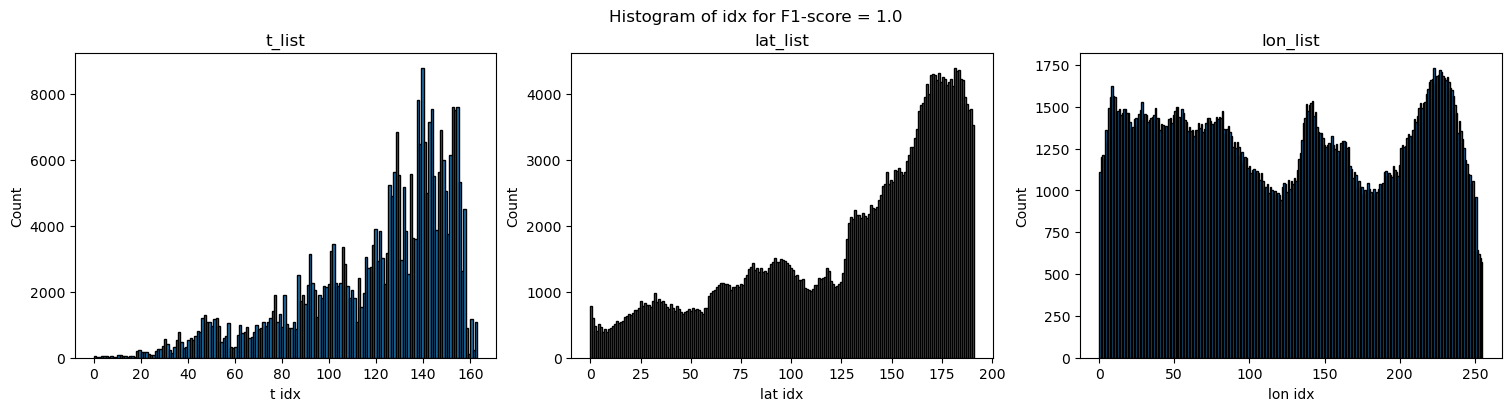

In [80]:
t_list = df_high_f1["time_idx"].values
lat_list = df_high_f1["lat_idx"].values
lon_list = df_high_f1["lon_idx"].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].hist(t_list, bins=len(ssp_truth_da.time), edgecolor="black")
axes[0].set_xlabel("t idx")
axes[0].set_ylabel("Count")
axes[0].set_title("t_list")

axes[1].hist(lat_list, bins=len(ssp_truth_da.lat), edgecolor="black")
axes[1].set_xlabel("lat idx")
axes[1].set_ylabel("Count")
axes[1].set_title("lat_list")

axes[2].hist(lon_list, bins=len(ssp_truth_da.lon), edgecolor="black")
axes[2].set_xlabel("lon idx")
axes[2].set_ylabel("Count")
axes[2].set_title("lon_list")

fig.suptitle("Histogram of idx for F1-score = 1.0")
plt.show()

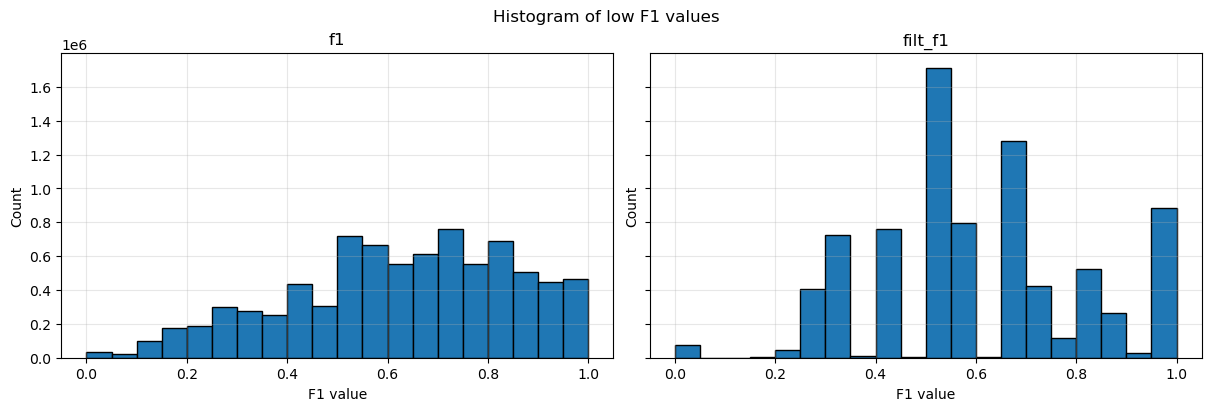

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True, sharey=True)

n1, _, _ = axes[0].hist(F1_score.flatten(), bins=20, edgecolor="black")
axes[0].set_title("f1")
axes[0].set_xlabel("F1 value")
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.3)

n2, _, _ = axes[1].hist(filt_F1_score.flatten(), bins=20, edgecolor="black")
axes[1].set_title("filt_f1")
axes[1].set_xlabel("F1 value")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.3)

ymax = max(n1.max(), n2.max()) * 1.05
for ax in axes:
    ax.set_ylim(0, ymax)

fig.suptitle("Histogram of low F1 values")
plt.show()

In [82]:
df_low_f1

,f1_value,time_idx,lat_idx,lon_idx
0,0.0,0,0,159
1,0.0,0,0,162
2,0.0,0,0,163
3,0.0,0,0,165
4,0.0,0,0,171
...,...,...,...,...
35216,0.0,163,181,255
35217,0.0,163,183,59
35218,0.0,163,184,60
35219,0.0,163,186,62


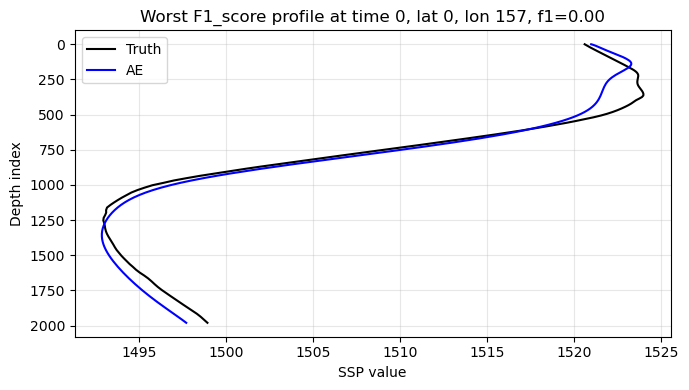

In [83]:
# cr = list(data_dict[k].keys())[0]
# (t,lat,lon),truth_prof, ae_prof =  data_dict[k][cr]['RMSE']['worst']['t_lat_lon']

t,lat,lon = filt_df_low_f1.iloc[0][["time_idx", "lat_idx", "lon_idx"]].astype(int).values
truth_prof = ssp_truth_da.isel(time=t, lat=lat, lon=lon).values
ae_prof = filt_ae[t, :, lat, lon]

plt.figure(figsize=(7, 4))
plt.plot(truth_prof, depth_array, label="Truth", c='k')
plt.plot(ae_prof, depth_array,  label="AE", c='b')
plt.ylabel("Depth index")
plt.xlabel("SSP value")
plt.gca().invert_yaxis()
plt.title(f"Worst F1_score profile at time {t}, lat {lat}, lon {lon}, f1={filt_F1_score[t, lat, lon]:.2f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

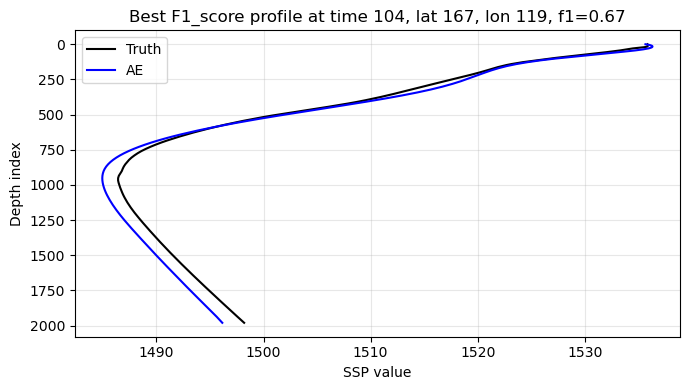

In [84]:
# cr = list(data_dict[k].keys())[0]
# (t,lat,lon),truth_prof, ae_prof =  data_dict[k][cr]['RMSE']['worst']['t_lat_lon']

t,lat,lon = df_best100_f1.iloc[0][["time_idx", "lat_idx", "lon_idx"]].astype(int).values
truth_prof = ssp_truth_da.isel(time=t, lat=lat, lon=lon).values
ae_prof = filt_ae[t, :, lat, lon]

plt.figure(figsize=(7, 4))
plt.plot(truth_prof, depth_array, label="Truth", c='k')
plt.plot(ae_prof, depth_array,  label="AE", c='b')
plt.ylabel("Depth index")
plt.xlabel("SSP value")
plt.gca().invert_yaxis()
plt.title(f"Best F1_score profile at time {t}, lat {lat}, lon {lon}, f1={filt_F1_score[t, lat, lon]:.2f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [85]:
f1_da = rmse_z.copy(data=F1_score)
filt_f1_da = rmse_z.copy(data=filt_F1_score)

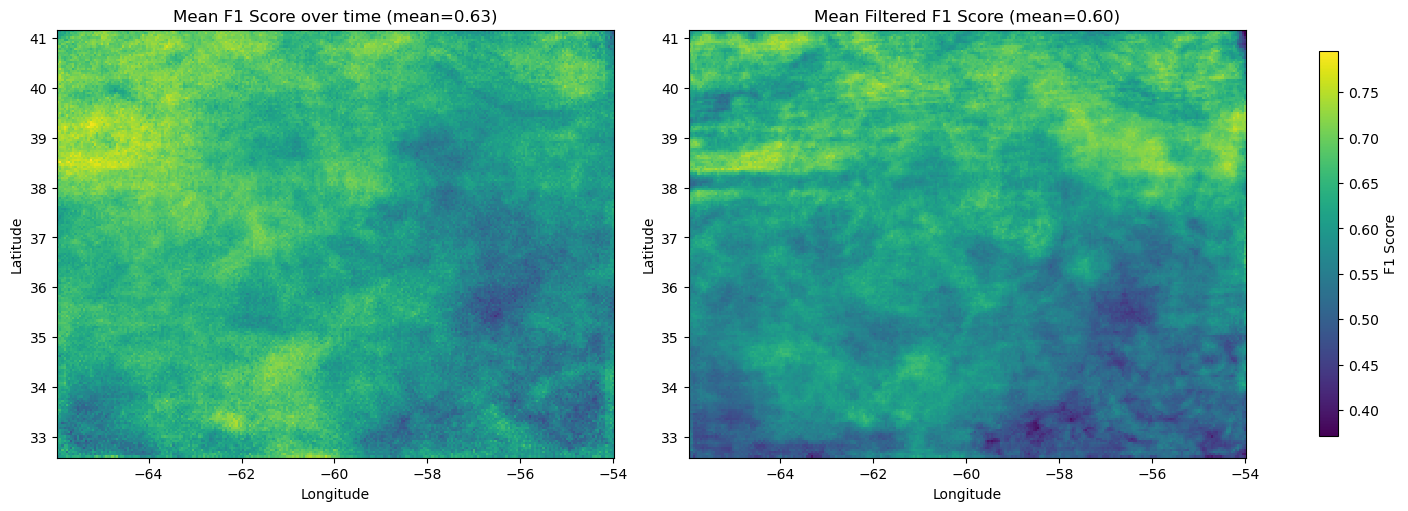

In [86]:


vmin = min(
    np.nanmin(f1_da.mean(dim="time").values),
    np.nanmin(filt_f1_da.mean(dim="time").values),
)
vmax = max(
    np.nanmax(f1_da.mean(dim="time").values),
    np.nanmax(filt_f1_da.mean(dim="time").values),
)


fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

pcm1 = axes[0].pcolormesh(
    f1_da["lon"].values,
    f1_da["lat"].values,
    f1_da.mean(dim="time").values,
    vmin=vmin,
    vmax=vmax,
    shading="auto"
)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title(f"Mean F1 Score over time (mean={f1_da.mean().values:.2f})")

pcm2 = axes[1].pcolormesh(
    f1_da["lon"].values,
    f1_da["lat"].values,
    filt_f1_da.mean(dim="time").values,
    vmin=vmin,
    vmax=vmax,
    shading="auto"
)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_title(f"Mean Filtered F1 Score (mean={filt_f1_da.mean().values:.2f})")

cbar = fig.colorbar(pcm2, ax=axes, shrink=0.9)
cbar.set_label("F1 Score")

plt.show()

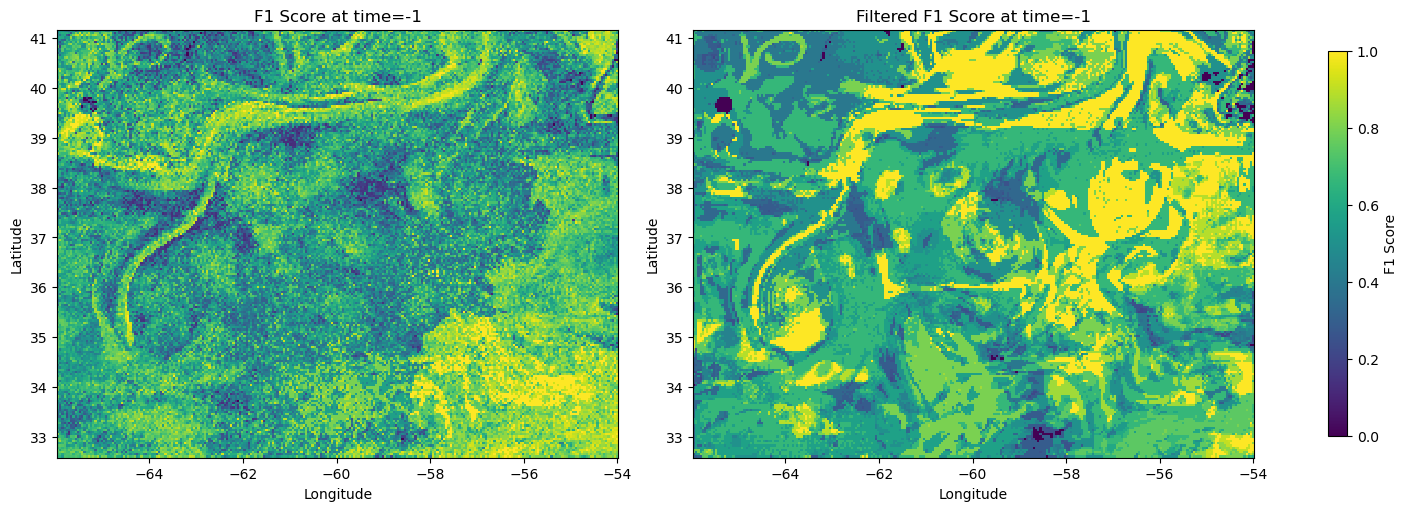

In [87]:
t = -1

vmin = min(
    np.nanmin(f1_da.isel(time=t).values),
    np.nanmin(filt_f1_da.isel(time=t).values),
)
vmax = max(
    np.nanmax(f1_da.isel(time=t).values),
    np.nanmax(filt_f1_da.isel(time=t).values),
)


fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

pcm1 = axes[0].pcolormesh(
    f1_da["lon"].values,
    f1_da["lat"].values,
    f1_da.isel(time=t).values,
    vmin=vmin,
    vmax=vmax,
    shading="auto"
)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title(f"F1 Score at time={t}")

pcm2 = axes[1].pcolormesh(
    f1_da["lon"].values,
    f1_da["lat"].values,
    filt_f1_da.isel(time=t).values,
    vmin=vmin,
    vmax=vmax,
    shading="auto"
)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_title(f"Filtered F1 Score at time={t}")

cbar = fig.colorbar(pcm2, ax=axes, shrink=0.9)
cbar.set_label("F1 Score")

plt.show()

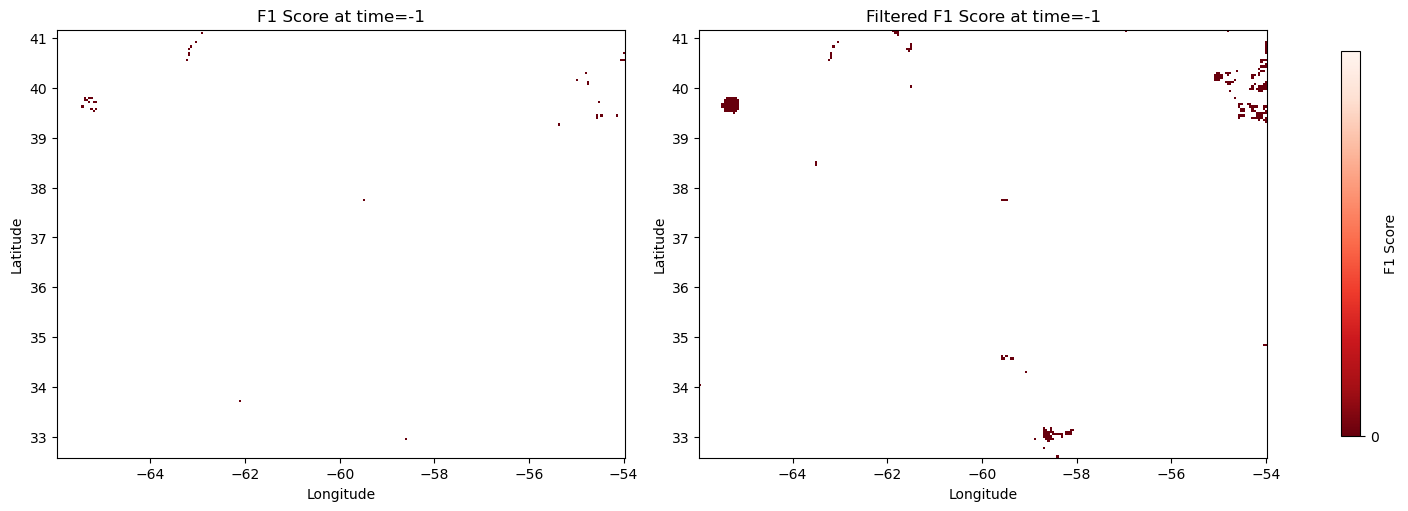

In [88]:
t = -1

# Set your range
vmin = 0.0
vmax = 0.0001  # must be > vmin

if vmax <= vmin:
    raise ValueError("vmax must be strictly greater than vmin.")

f1_t = f1_da.isel(time=t)
filt_f1_t = filt_f1_da.isel(time=t)

# Keep only values within [vmin, vmax]
f1_t_low = f1_t.where((f1_t >= vmin) & (f1_t <= vmax))
filt_f1_t_low = filt_f1_t.where((filt_f1_t >= vmin) & (filt_f1_t <= vmax))

cmap = plt.cm.Reds_r.copy()
cmap.set_bad("white")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

pcm1 = axes[0].pcolormesh(
    f1_da["lon"].values,
    f1_da["lat"].values,
    f1_t_low.values,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    shading="auto"
)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title(f"F1 Score at time={t}")

pcm2 = axes[1].pcolormesh(
    f1_da["lon"].values,
    f1_da["lat"].values,
    filt_f1_t_low.values,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    shading="auto"
)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_title(f"Filtered F1 Score at time={t}")

ticks = np.round(np.arange(vmin, vmax + 1e-9, 0.1), 1)
cbar = fig.colorbar(pcm2, ax=axes, shrink=0.9, ticks=ticks)
cbar.set_label("F1 Score")
cbar.ax.set_ylim(vmin, vmax)

plt.show()


# STD

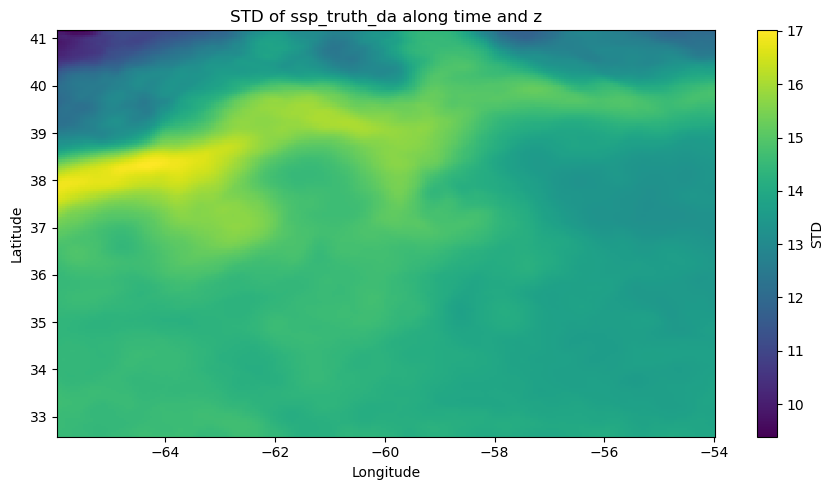

In [89]:
std_time_z = ssp_truth_da.std(dim=("time", "z"), skipna=True)

plt.figure(figsize=(9, 5))
pcm = plt.pcolormesh(
    std_time_z["lon"].values,
    std_time_z["lat"].values,
    std_time_z.values,
    shading="auto"
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("STD of ssp_truth_da along time and z")
cbar = plt.colorbar(pcm)
cbar.set_label("STD")
plt.tight_layout()
plt.show()

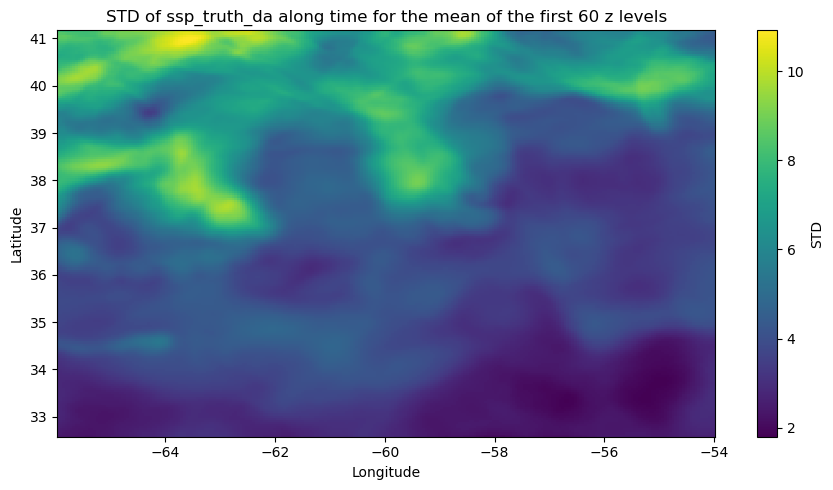

In [90]:
std_time = ssp_truth_da.isel(z=slice(0,60)).mean(dim="z").std(dim=("time"), skipna=True)

plt.figure(figsize=(9, 5))
pcm = plt.pcolormesh(
    std_time["lon"].values,
    std_time["lat"].values,
    std_time.values,
    shading="auto"
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("STD of ssp_truth_da along time for the mean of the first 60 z levels")
cbar = plt.colorbar(pcm)
cbar.set_label("STD")
plt.tight_layout()
plt.show()

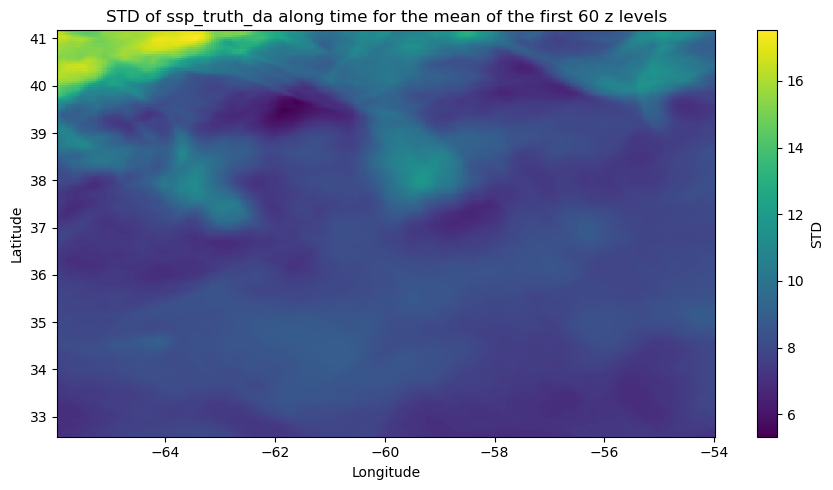

In [91]:
std_time = ssp_truth_da.isel(z=0).std(dim=("time"), skipna=True)

plt.figure(figsize=(9, 5))
pcm = plt.pcolormesh(
    std_time["lon"].values,
    std_time["lat"].values,
    std_time.values,
    shading="auto"
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("STD of ssp_truth_da along time for the mean of the first 60 z levels")
cbar = plt.colorbar(pcm)
cbar.set_label("STD")
plt.tight_layout()
plt.show()

# Classification of profiles

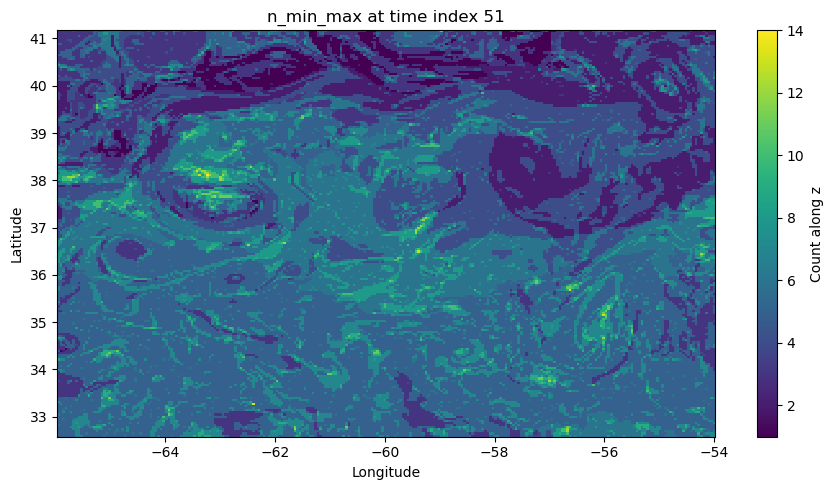

In [92]:
t = 51

# Count min/max-change markers along depth axis, then select one time slice
if hasattr(min_max_idx_truth, "isel"):  # xarray case
    n_min_max = min_max_idx_truth.sum(axis=1).isel(time=t)
    n_min_max_vals = n_min_max.values
else:  # numpy case
    n_min_max = np.asarray(min_max_idx_truth).sum(axis=1)[t]  # (lat, lon)
    n_min_max_vals = n_min_max

plt.figure(figsize=(9, 5))
pcm = plt.pcolormesh(
    ssp_truth_da["lon"].values,
    ssp_truth_da["lat"].values,
    n_min_max_vals,
    shading="auto"
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"n_min_max at time index {t}")
cbar = plt.colorbar(pcm)
cbar.set_label("Count along z")
plt.tight_layout()
plt.show()

In [ ]:
# min_max_idx_140_truth = get_min_max_idx(ssp_da_140,axs=1, pad=False)

NameError: name 'ssp_da_140' is not defined

In [ ]:
# n_min_max_140 = np.asarray(min_max_idx_140_truth).sum(axis=1)  # shape: (time, lat, lon)

# flat_idx = np.nanargmax(n_min_max_140)
# t_idx, lat_idx, lon_idx = np.unravel_index(flat_idx, n_min_max_140.shape)

# print(f"(t, lat, lon) idx = ({t_idx}, {lat_idx}, {lon_idx})")
# print(f"max value = {n_min_max_140[t_idx, lat_idx, lon_idx]}")

(t, lat, lon) idx = (15, 100, 16)
max value = 14.0


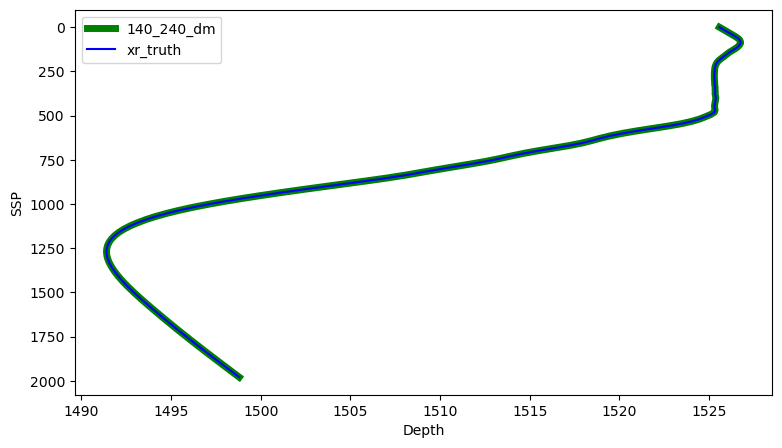

In [ ]:
# t = ssp_da_140.time.values[t_idx]
# lat = ssp_da_140.lat.values[lat_idx]
# lon = ssp_da_140.lon.values[lon_idx]

# ssp_140_prof = ssp_da_140.isel(time=t_idx, lat=lat_idx, lon=lon_idx).values
# ssp_xr = xr_truth.sel(time=t, lat=lat, lon=lon, method='nearest').isel(z=slice(0,len(depth_array)) ).values

# plt.figure(figsize=(9, 5))
# plt.plot( ssp_140_prof, depth_array, label="140_240_dm", lw=5,c='g')
# plt.plot(ssp_xr, depth_array, label="xr_truth",c='b')
# plt.gca().invert_yaxis()
# plt.xlabel("Depth")
# plt.ylabel("SSP")
# plt.legend()
# plt.show()


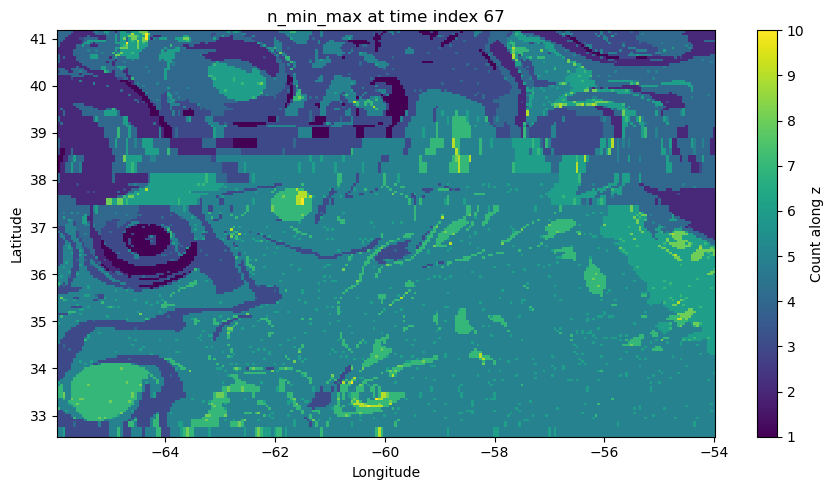

In [ ]:
# t = 67

# # Count min/max-change markers along depth axis, then select one time slice
# if hasattr(min_max_idx_140_truth, "isel"):  # xarray case
#     n_min_max = min_max_idx_140_truth.sum(axis=1).isel(time=t)
#     n_min_max_vals = n_min_max.values
# else:  # numpy case
#     n_min_max = np.asarray(min_max_idx_140_truth).sum(axis=1)[t]  # (lat, lon)
#     n_min_max_vals = n_min_max

# plt.figure(figsize=(9, 5))
# pcm = plt.pcolormesh(
#     ssp_da_140["lon"].values,
#     ssp_da_140["lat"].values,
#     n_min_max_vals,
#     shading="auto"
# )
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.title(f"n_min_max at time index {t}")
# cbar = plt.colorbar(pcm)
# cbar.set_label("Count along z")
# plt.tight_layout()
# plt.show()

In [ ]:
# t = 51

# # Count min/max-change markers along depth axis, then select one time slice
# if hasattr(min_max_idx_xr_truth, "isel"):  # xarray case
#     n_min_max = min_max_idx_xr_truth.sum(axis=1).isel(time=t)
#     n_min_max_vals = n_min_max.values
# else:  # numpy case
#     n_min_max = np.asarray(min_max_idx_xr_truth).sum(axis=1)[t]  # (lat, lon)
#     n_min_max_vals = n_min_max

# plt.figure(figsize=(9, 5))
# pcm = plt.pcolormesh(
#     ssp_truth_da["lon"].values,
#     ssp_truth_da["lat"].values,
#     n_min_max_vals,
#     shading="auto"
# )
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.title(f"n_min_max at time index {t}")
# cbar = plt.colorbar(pcm)
# cbar.set_label("Count along z")
# plt.tight_layout()
# plt.show()

NameError: name 'min_max_idx_xr_truth' is not defined

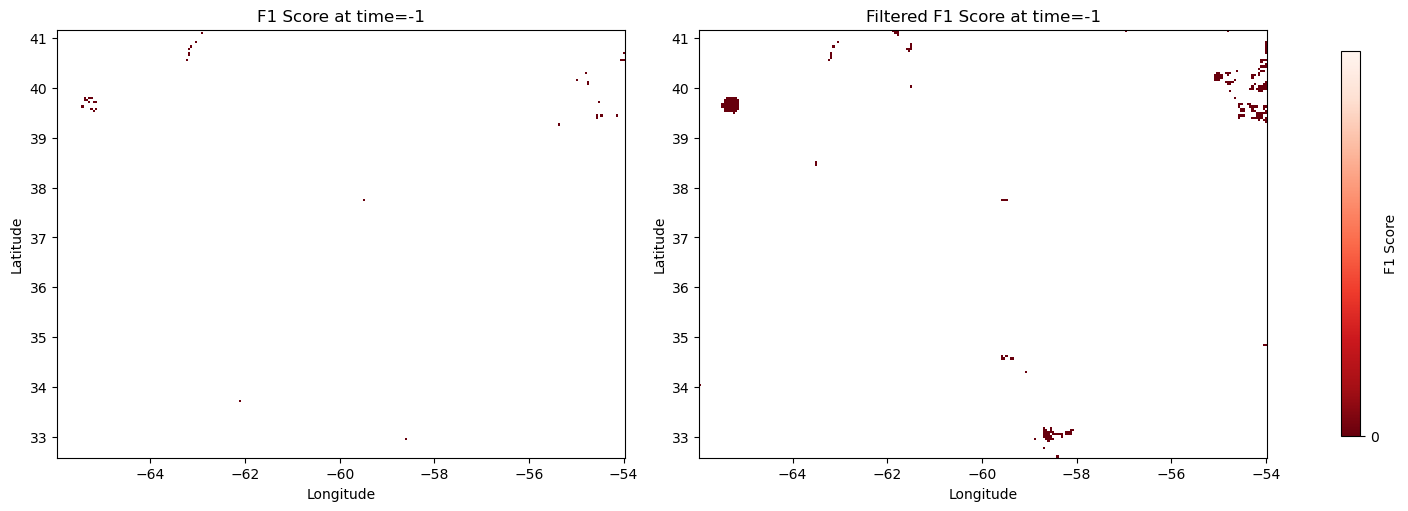

In [94]:
t = -1

# Set your range
vmin = 0.0
vmax = 0.0001  # must be > vmin

if vmax <= vmin:
    raise ValueError("vmax must be strictly greater than vmin.")

f1_t = f1_da.isel(time=t)
filt_f1_t = filt_f1_da.isel(time=t)

# Keep only values within [vmin, vmax]
f1_t_low = f1_t.where((f1_t >= vmin) & (f1_t <= vmax))
filt_f1_t_low = filt_f1_t.where((filt_f1_t >= vmin) & (filt_f1_t <= vmax))

cmap = plt.cm.Reds_r.copy()
cmap.set_bad("white")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

pcm1 = axes[0].pcolormesh(
    f1_da["lon"].values,
    f1_da["lat"].values,
    f1_t_low.values,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    shading="auto"
)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title(f"F1 Score at time={t}")

pcm2 = axes[1].pcolormesh(
    f1_da["lon"].values,
    f1_da["lat"].values,
    filt_f1_t_low.values,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    shading="auto"
)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_title(f"Filtered F1 Score at time={t}")

ticks = np.round(np.arange(vmin, vmax + 1e-9, 0.1), 1)
cbar = fig.colorbar(pcm2, ax=axes, shrink=0.9, ticks=ticks)
cbar.set_label("F1 Score")
cbar.ax.set_ylim(vmin, vmax)

plt.show()


100%|██████████| 6/6 [27:45<00:00, 277.62s/it]


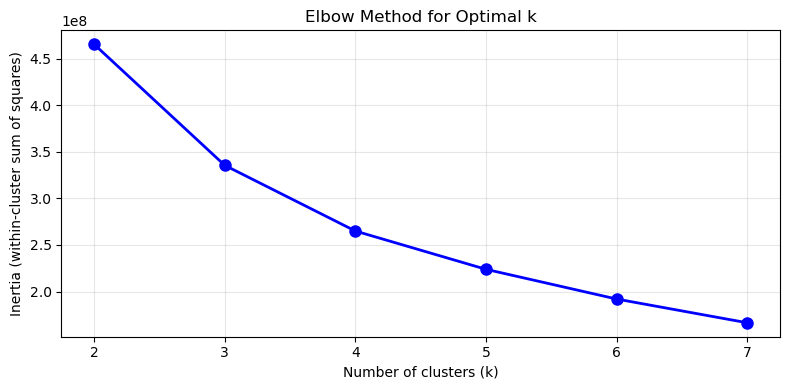

In [95]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Reshape: (time, z, lat, lon) -> (n_profiles, n_depths)
data = ssp_truth_da.values

#n_time, n_z, n_lat, n_lon = data.shape
#profiles = data.transpose(0, 2, 3, 1).reshape(-1, n_z)  # (n_samples, n_depths)

#data = np.mean(data,axis=0) 
# data = data[t,...] 
# n_time = 1
n_t, n_z, n_lat, n_lon = data.shape
profiles = data.transpose(0, 2, 3, 1).reshape(-1, n_z)  # (n_samples, n_depths)

# # Remove profiles with NaNs
# valid_mask = ~np.isnan(profiles).any(axis=1)
# profiles_valid = profiles[valid_mask]

# Standardize profiles (important for shape-based clustering)
scaler = StandardScaler()
profiles_scaled = scaler.fit_transform(profiles)

# Elbow method: compute inertia for k=2 to k=15
k_range = range(2, 8)
inertias = []
for k in tqdm(k_range):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(profiles_scaled)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method for Optimal k")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

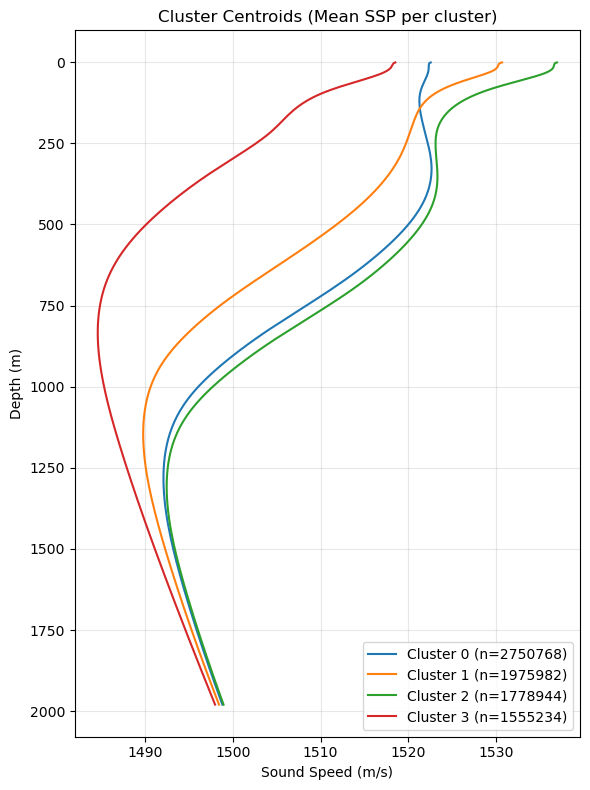

In [96]:
# Fit with chosen k
k_opt = 4  # adjust based on elbow plot
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels = kmeans.fit_predict(profiles_scaled)

# Plot cluster centroids (mean profile shapes)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)  # back to original scale
depth = ssp_truth_da.z.values

plt.figure(figsize=(6, 8))
for i in range(k_opt):
    plt.plot(centroids[i], depth, label=f"Cluster {i} (n={np.sum(labels==i)})")
plt.gca().invert_yaxis()
plt.xlabel("Sound Speed (m/s)")
plt.ylabel("Depth (m)")
plt.title("Cluster Centroids (Mean SSP per cluster)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2604753/3678682261.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab10', k_opt)


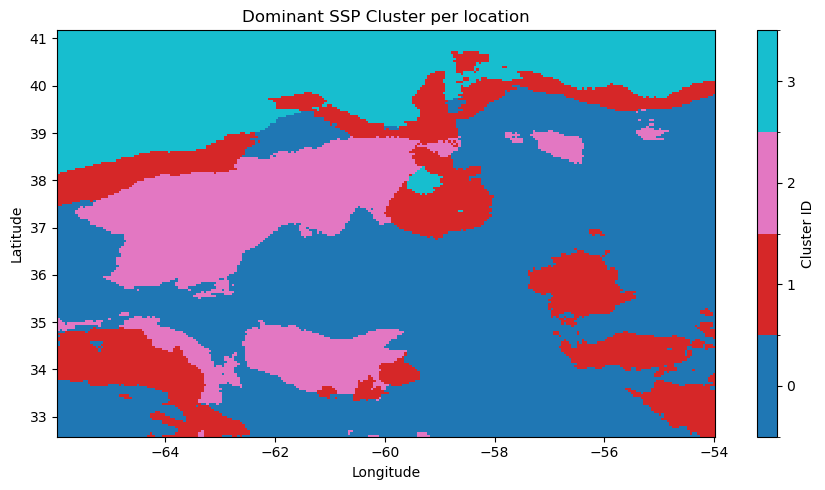

In [97]:
import matplotlib.colors as mcolors
from matplotlib.cm import get_cmap

# Map labels back to original shape
labels_map = labels.reshape(n_t, n_lat, n_lon)

# Show dominant cluster per (lat, lon) across time
from scipy import stats
dominant_cluster = np.apply_along_axis(
    lambda x: stats.mode(x[~np.isnan(x)], keepdims=False)[0] if np.any(~np.isnan(x)) else np.nan,
    axis=0, arr=labels_map
)

# Create discrete colormap with k_opt colors
cmap = get_cmap('tab10', k_opt)
norm = mcolors.BoundaryNorm(boundaries=np.arange(-0.5, k_opt + 0.5, 1), ncolors=k_opt)

plt.figure(figsize=(9, 5))
plt.pcolormesh(ssp_truth_da.lon.values, ssp_truth_da.lat.values, dominant_cluster, 
               cmap=cmap, norm=norm, shading='auto')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Dominant SSP Cluster per location")
cbar = plt.colorbar(label="Cluster ID", ticks=np.arange(k_opt))
plt.tight_layout()
plt.show()

In [98]:
df_high_rmse

,rmse_value,time_idx,lat_idx,lon_idx
2782,7.839458,117,168,255
2779,7.705806,117,167,255
2555,7.269823,112,160,255
2739,7.258575,116,166,255
588,7.225788,56,191,221
...,...,...,...,...
737,4.000248,60,188,204
3086,4.000103,133,157,91
1999,4.000076,93,188,105
648,4.000041,58,171,14


In [99]:
df_low_rmse

,rmse_value,time_idx,lat_idx,lon_idx
4722,0.373272,1,3,203
4617,0.390434,1,2,203
4721,0.395978,1,3,202
4831,0.396888,1,4,203
4830,0.408534,1,4,202
...,...,...,...,...
141934,0.999999,32,1,231
41435,1.000000,9,30,121
339135,1.000000,115,4,211
348924,1.000000,147,90,218


In [100]:
data = []

for t,lat,lon in zip(df_high_rmse.iloc[:]["time_idx"], df_high_rmse.iloc[:]["lat_idx"], df_high_rmse.iloc[:]["lon_idx"]):
    profile = ssp_truth_da.isel(time=t, lat=lat, lon=lon).values
    data.append(profile)


data = np.array(data)  # shape: (n_samples, n_depths)

# # Remove profiles with NaNs
# valid_mask = ~np.isnan(profiles).any(axis=1)
# profiles_valid = profiles[valid_mask]

# Standardize profiles (important for shape-based clustering)
scaler = StandardScaler()
profiles_scaled = scaler.fit_transform(data)


100%|██████████| 4/4 [00:00<00:00,  7.62it/s]


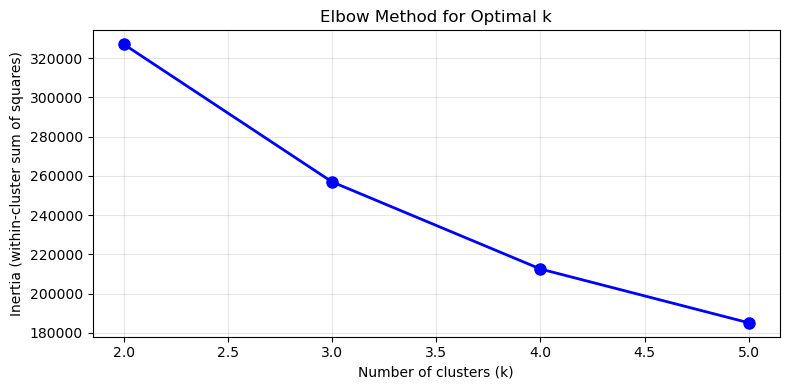

In [101]:

# Elbow method: compute inertia for k=2 to k=15
k_range = range(2, 6)
inertias = []
for k in tqdm(k_range):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(profiles_scaled)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method for Optimal k")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

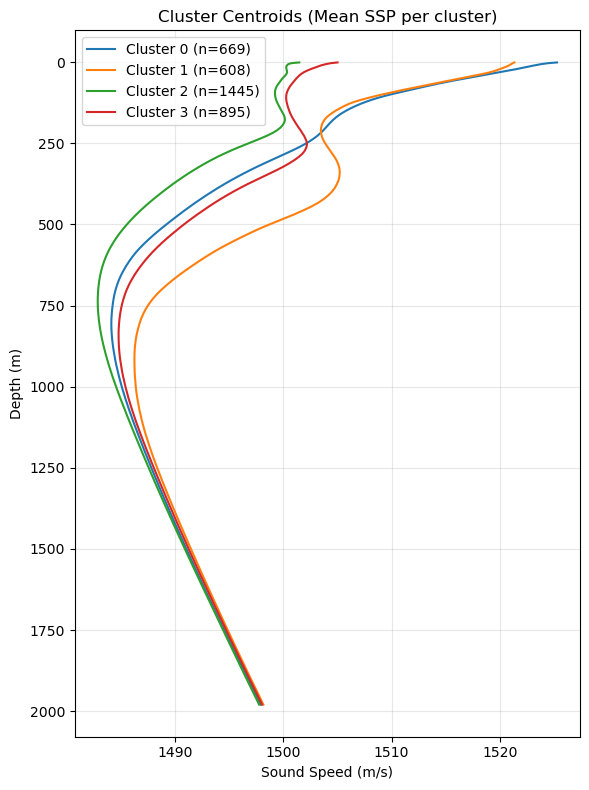

In [102]:
# Fit with chosen k
k_opt = 4  # adjust based on elbow plot
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels = kmeans.fit_predict(profiles_scaled)

# Plot cluster centroids (mean profile shapes)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)  # back to original scale
depth = ssp_truth_da.z.values

plt.figure(figsize=(6, 8))
for i in range(k_opt):
    plt.plot(centroids[i], depth, label=f"Cluster {i} (n={np.sum(labels==i)})")
plt.gca().invert_yaxis()
plt.xlabel("Sound Speed (m/s)")
plt.ylabel("Depth (m)")
plt.title("Cluster Centroids (Mean SSP per cluster)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

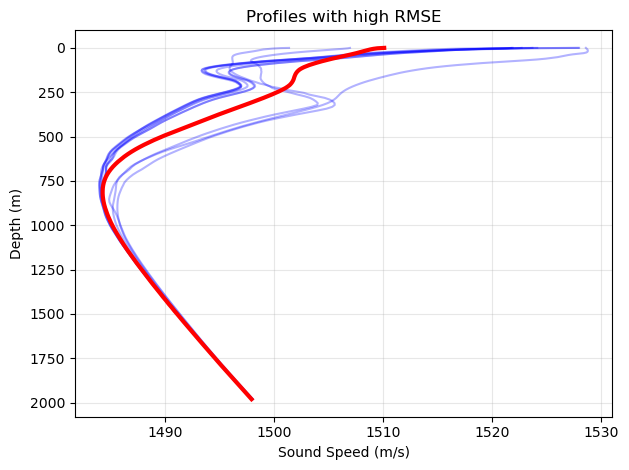

In [103]:
for t,lat,lon in zip(df_high_rmse.iloc[:10]["time_idx"], df_high_rmse.iloc[:10]["lat_idx"], df_high_rmse.iloc[:10]["lon_idx"]):
    prof = ssp_truth_da.isel(time=t, lat=lat, lon=lon).values
    plt.plot(prof, depth, c='b', alpha=0.3)

plt.plot(np.mean(data, axis=0), depth, c='r', label="Mean profile", lw=3)
plt.gca().invert_yaxis()
plt.xlabel("Sound Speed (m/s)")
plt.ylabel("Depth (m)")
plt.title("Profiles with high RMSE")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

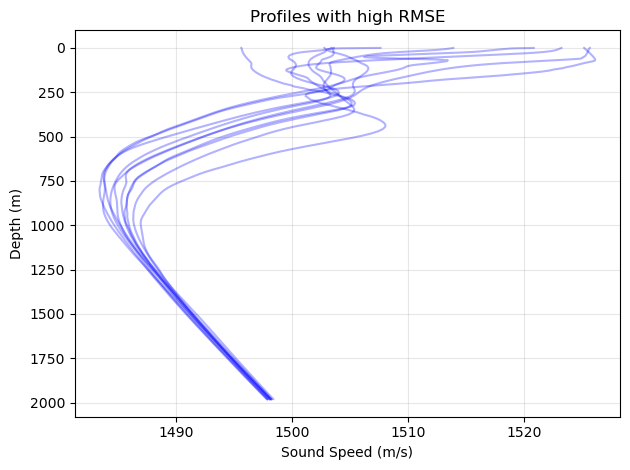

In [104]:
for t,lat,lon in zip(df_high_rmse.iloc[-10:]["time_idx"], df_high_rmse.iloc[-10:]["lat_idx"], df_high_rmse.iloc[-10:]["lon_idx"]):
    prof = ssp_truth_da.isel(time=t, lat=lat, lon=lon).values
    plt.plot(prof, depth, c='b', alpha=0.3)
plt.gca().invert_yaxis()
plt.xlabel("Sound Speed (m/s)")
plt.ylabel("Depth (m)")
plt.title("Profiles with high RMSE")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

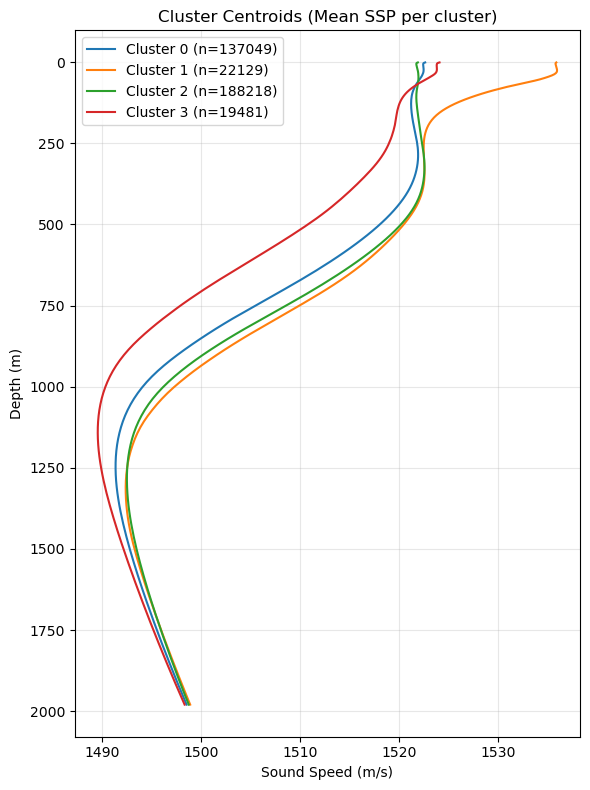

In [105]:
data = []

for t,lat,lon in zip(df_low_rmse.iloc[:]["time_idx"], df_low_rmse.iloc[:]["lat_idx"], df_low_rmse.iloc[:]["lon_idx"]):
    profile = ssp_truth_da.isel(time=t, lat=lat, lon=lon).values
    data.append(profile)


data = np.array(data)  # shape: (n_samples, n_depths)

# # Remove profiles with NaNs
# valid_mask = ~np.isnan(profiles).any(axis=1)
# profiles_valid = profiles[valid_mask]

# Standardize profiles (important for shape-based clustering)
scaler = StandardScaler()
profiles_scaled = scaler.fit_transform(data)


# Fit with chosen k
k_opt = 4  # adjust based on elbow plot
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels = kmeans.fit_predict(profiles_scaled)

# Plot cluster centroids (mean profile shapes)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)  # back to original scale
depth = ssp_truth_da.z.values

plt.figure(figsize=(6, 8))
for i in range(k_opt):
    plt.plot(centroids[i], depth, label=f"Cluster {i} (n={np.sum(labels==i)})")
plt.gca().invert_yaxis()
plt.xlabel("Sound Speed (m/s)")
plt.ylabel("Depth (m)")
plt.title("Cluster Centroids (Mean SSP per cluster)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
